Diana Itzel Soto Castañeda

Ciencia de Datos para Sensores Inteligentes

# Proyecto - Wave2Ripeness

## Introducción

Para este proyecto se emplea un sistema de sensado en radiofrecuencia y microondas *free-space* para analizar la respuesta electromagnética de muestras de aguacate durante su proceso de maduración. Los parámetros de dispersión (parámetros-S), obtenidos a partir de las mediciones, se procesan para extraer características las cuales se utilizan como variables de entrada para modelos de aprendizaje automático.

## Objetivo

El objetivo de este proyecto es evaluar si la información obtenida mediante un montaje experimental de sensado con microondas, combinado con técnicas de aprendizaje automático, es suficiente para clasificar muestras de aguacate en tres estados de maduración: verde, maduro (en punto) y pasado.

## Descripción del *set-up* experimental y etiquetado 

In [3]:
import glob
import os

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import skrf as rf
from matplotlib import pyplot as plt
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

Se midierón 49 aguacates a lo largo de 8 días.
Los aguacates se colocarón alineados a un sistema de antenas de corneta SAS-571 -las cuales cuentan con un ancho de haz de 30 grados y son ideales para mediciones de Interferencia Electromagnética-.
Cada aguacate se midió en tres posiciones. Las tres posiciones corresponden a diferentes orientaciones del fruto alrededor de su eje longitudinal (el eje longitudinal es el nombre del eje más largo, va desde el ápice del fruto hasta el extremo del pedúnculo).

Para cada posición de cada muestra se realizaron mediciones de microondas en tres bandas de frecuencia distintas. Adicionalmente, se tomó una fotografía de cada muestra como referencia geométrica, considerando que en mediciones de microondas la geometría y la orientación del objeto pueden influir significativamente en la respuesta obtenida.
| Variable    | Etiqueta | Comentarios                                                                                                                       |
| ----------- | -------- | --------------------------------------------------------------------------------------------------------------------------------- |
| ID Acuacate | A##     | Cada aguacate tiene su ID desde A01 hasta A049                                                                                                          |
| Día         | D##      | Día desde la primera media                                                                                                        |
| Banda       | B#       | B1 - $700 \text{ MHz a } 1.8 \text{ GHz}$<br>B2 - $1.8 \text{ GHz a } 3.5 \text{ GHz}$<br>B3 - $3.5 \text{ GHz a } 6 \text{ G}Hz$ |
| Orientación | O###     | O000 - Posición de inicio<br>O120 - 120 grados de rotación<br>O240 - 240 grados de rotación                                       |



Ejemplo de nombre de la medida de parámetros S de un aguacate: 
A02_D03_B2_O120

Set-up experimental:

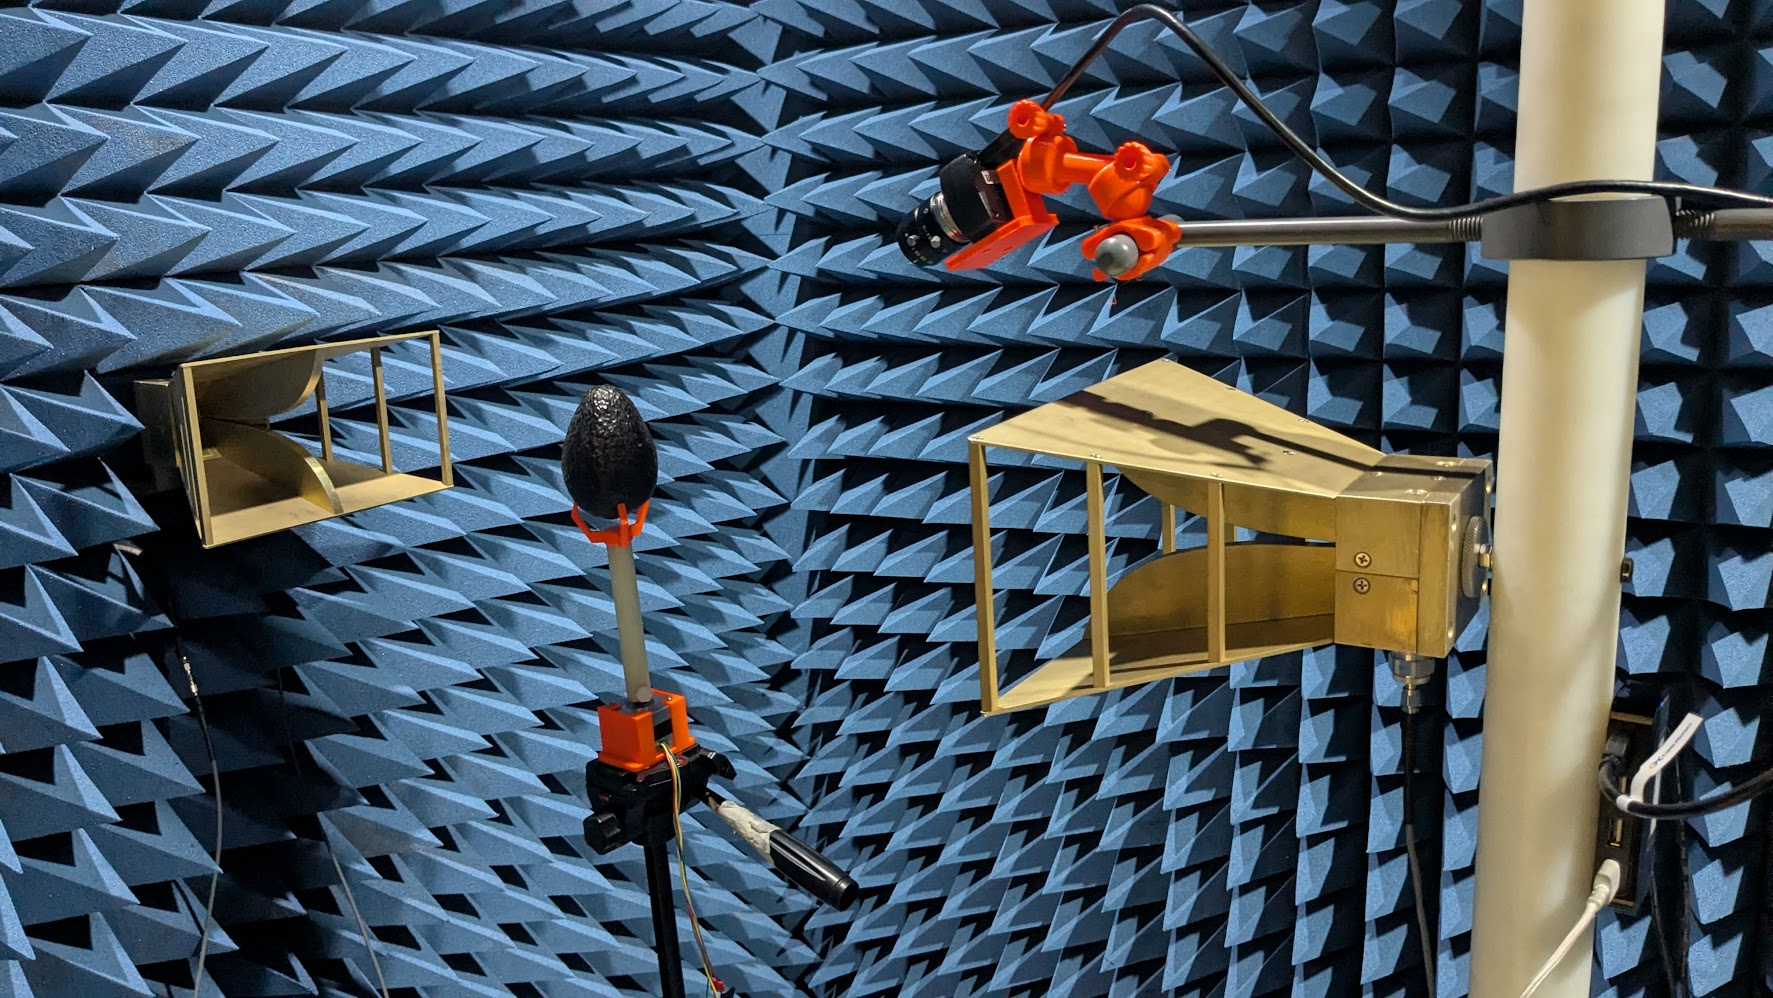

Para cada medida se obtienen los parámetros de dispersión S11, S12, S21 y S22 empleando de un Analizador de Redes Vectoriales Agilent 8753ES

Antes de la medida diaria, se evaluó el estado de madurez del aguacate —de forma empírica— por su tacto y apariencia y se clasificó en alguno de los tres estados: verde, maduro (en punto) o pasado.

### Carga de etiquetas

<StringArray>
['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08']
Length: 8, dtype: str
Total de etiquetas: 363


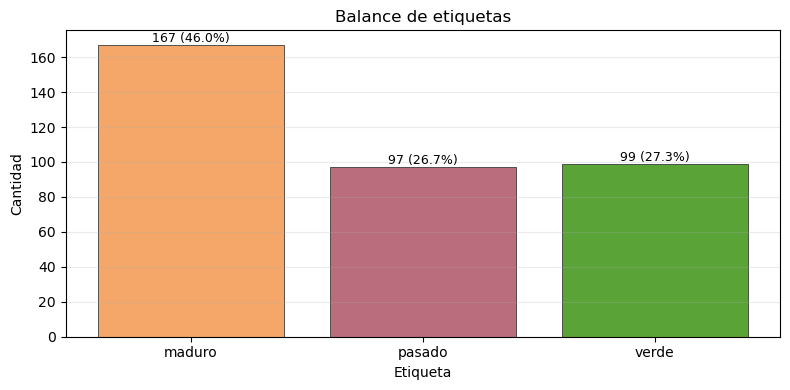

Mostrando 10 de 363 pares:
(A01, D01) -> verde
(A02, D01) -> verde
(A03, D01) -> verde
(A04, D01) -> verde
(A05, D01) -> verde
(A06, D01) -> verde
(A07, D01) -> verde
(A08, D01) -> verde
(A09, D01) -> verde
(A10, D01) -> verde


In [4]:
def parse_key(name):
    """Parsea el nombre de una medida y extrae sus componentes principales."""
    base_name = Path(name).stem
    parts = base_name.split('_')

    parsed = {
        'raw_name': base_name,
        'sample_code': None,
        'day_code': None,
        'band': None,
        'orientation': None,
        'is_air': False,
    }

    if not parts:
        return parsed

    if parts[0] == 'AIR':
        parsed['is_air'] = True
        parsed['day_code'] = next((part for part in parts if part.startswith('D')), None)
        parsed['band'] = next((part for part in parts if part.startswith('B')), None)
        return parsed

    parsed['sample_code'] = parts[0]
    parsed['day_code'] = next((part for part in parts if part.startswith('D')), None)
    parsed['band'] = next((part for part in parts if part.startswith('B')), None)
    parsed['orientation'] = next((part for part in parts if part.startswith('O')), None)
    return parsed

def load_metadata_csvs(folder='data/metadata', pattern='*.csv'):
    """Carga y concatena los CSV de metadatos agregando la columna day_code."""
    files = glob.glob(os.path.join(folder, pattern))
    dfs = []

    for f in files:
        df = pd.read_csv(f)
        day = os.path.basename(f).split('_')[0]  # D01, D02...
        df['day_code'] = day
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError(f'No se encontraron archivos {pattern} en {folder}')

    meta = pd.concat(dfs, ignore_index=True)
    meta['sample_code'] = meta['sample_code'].str.strip()
    meta['day_code'] = meta['day_code'].str.strip()
    return meta

def build_label_dict(meta, sample_col='sample_code', day_col='day_code', label_col='percepcion_madurez'):
    """Construye un diccionario de etiquetas con llave (sample_code, day_code)."""
    required_cols = {sample_col, day_col, label_col}
    missing_cols = required_cols.difference(meta.columns)
    if missing_cols:
        raise KeyError(f'Faltan columnas requeridas en meta: {sorted(missing_cols)}')

    label_dict = {}
    for _, row in meta.iterrows():
        key = (row[sample_col], row[day_col])
        label_dict[key] = row[label_col]
    return label_dict

def load_labels(folder='data/metadata', label_col='percepcion_madurez'):
    """Función principal para cargar metadatos y generar el diccionario de etiquetas."""
    meta = load_metadata_csvs(folder=folder)
    label_dict = build_label_dict(meta, label_col=label_col)
    return meta, label_dict


MATURITY_COL = 'percepcion_madurez'
meta, label_dict = load_labels(folder='data/metadata', label_col=MATURITY_COL)
meta.head()
print(meta['day_code'].unique())
print(f'Total de etiquetas: {len(label_dict)}')

# Gráfico de balance de etiquetas
label_col = MATURITY_COL
label_counts = meta[label_col].value_counts(dropna=False).sort_index()
label_pct = (label_counts / label_counts.sum() * 100).round(1)
labels = label_counts.index.astype(str).tolist()

# Colores por etiqueta (fallback automático para clases nuevas)
label_color_map = {
    'verde': "#509E2C",
    'maduro': '#F4A261',
    'pasado': '#B56576',
}
fallback_colors = sns.color_palette('Set2', n_colors=len(labels)).as_hex()
bar_colors = [
    label_color_map.get(label.lower(), fallback_colors[i])
    for i, label in enumerate(labels)
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    labels,
    label_counts.values,
    color=bar_colors,
    edgecolor='#333333',
    linewidth=0.6,
    alpha=0.95,
)
ax.set_title('Balance de etiquetas')
ax.set_xlabel('Etiqueta')
ax.set_ylabel('Cantidad')
ax.grid(axis='y', alpha=0.25)

for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count} ({pct}%)',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Mostrar etiquetas de A21 por dia
#a21_labels = (
#    meta.loc[meta['sample_code'] == 'A21', ['day_code', label_col]]
#    .dropna(subset=[label_col])
#    .drop_duplicates()
#    .sort_values('day_code')
#)

#print('\nEtiquetas de A21 por dia:')
#if a21_labels.empty:
#    print('No se encontraron registros para A21 en metadatos.')
#else:
#    display(a21_labels.rename(columns={'day_code': 'dia', label_col: 'etiqueta'}))

# Mostrar ejemplo
n = 10
sample_items = list(label_dict.items())[:n]

print(f"Mostrando {len(sample_items)} de {len(label_dict)} pares:")
for (sample_code, day_code), label in sample_items:
    print(f"({sample_code}, {day_code}) -> {label}")

## Exploración de Datos

La exploración de datos se realizó con el objetivo de identificar patrones, tendencias y posibles inconsistencias en las mediciones obtenidas. Se analizaron las variables relacionadas con la respuesta en microondas, así como la variabilidad entre muestras, posiciones y bandas de frecuencia. Este análisis permitió evaluar la calidad de los datos y orientar las decisiones para su posterior procesamiento y modelado:

### Función para carga de los datos, graficado y separación en bandas de frecuencia medidas

Los datos se cargan en un diccionario conformado por redes de dos puertos en formato touchstone usando la librería scikit-rf de python

In [5]:
def load_networks(data_dir='./data'):

    """
    Carga los archivos .s2p (Parámetros S) de una carpeta y los almacena en un diccionario
    """

    #Definir el directorio con los archivos .s2p
    data_dir = Path(data_dir)

    networks = {} # Diccionario para almacenar los objetos Network con el nombre del archivo como clave

    #Iterar sobre los archivos .s2p en el directorio
    for s2p_file in data_dir.glob('*.s2p'):
        #print(f'Procesando archivo: {s2p_file.name}')
        network_name = s2p_file.name.split('.')[0]  # Obtener el nombre del archivo sin extensión
        # Cargar el archivo .s2p como un objeto Network
        network = rf.Network(s2p_file)
        # Almacenar el objeto Network en el diccionario
        networks[network_name] = network
    
    return networks



Se crean funciones para el graficado de los datos con el objetivo de poder hacer una inspección de la calidad del sistema de sensado.

In [6]:
def plot_s_parameters_sameplot(networks, title='Parámetros S', show_legend=False, legend_kwargs=None):
    """
    Plotea los parámetros S de todas las Networks en la misma figura.

    Parámetros
    ----------
    show_legend : bool
        Si es True, muestra la leyenda en cada subplot.
    legend_kwargs : dict | None
        Argumentos opcionales para axis.legend().
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    fig.suptitle(title)

    s_terms = [
        ('S11', (0, 0)),
        ('S21', (1, 0)),
        ('S12', (0, 1)),
        ('S22', (1, 1)),
    ]

    if legend_kwargs is None:
        legend_kwargs = {'fontsize': 'small'}

    for axis, (label, (row, col)) in zip(axes.flat, s_terms):
        for name, network in networks.items():
            axis.plot(
                network.f,
                20 * np.log10(np.abs(network.s[:, row, col])),
                label=name,
            )

        axis.set_title(label)
        axis.set_xlabel('Frecuencia (Hz)')
        axis.set_ylabel('Magnitud (dB)')
        axis.grid(True)

        if show_legend:
            axis.legend(**legend_kwargs)

    plt.tight_layout()
    plt.show()
    return fig
def plot_s_parameters_real_and_imag(networks, title='Parámetros S', show_legend=False, legend_kwargs=None):
    """
    Plotea los parámetros S de todas las Networks en la misma figura, mostrando parte real e imaginaria.

    Parámetros
    ----------
    show_legend : bool
        Si es True, muestra la leyenda en cada subplot.
    legend_kwargs : dict | None
        Argumentos opcionales para axis.legend().
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    fig.suptitle(title)

    s_terms = [
        ('S11', (0, 0)),
        ('S21', (1, 0)),
        ('S12', (0, 1)),
        ('S22', (1, 1)),
    ]

    if legend_kwargs is None:
        legend_kwargs = {'fontsize': 'small'}

    for axis, (label, (row, col)) in zip(axes.flat, s_terms):
        for name, network in networks.items():
            axis.plot(
                network.f,
                np.real(network.s[:, row, col]),
                label=f'{name} - Real',
                linestyle='-',
            )
            axis.plot(
                network.f,
                np.imag(network.s[:, row, col]),
                label=f'{name} - Imag',
                linestyle='--',
            )

        axis.set_title(label)
        axis.set_xlabel('Frecuencia (Hz)')
        axis.set_ylabel('Valor')
        axis.grid(True)

        if show_legend:
            axis.legend(**legend_kwargs)

    plt.tight_layout()
    plt.show()
    return fig
def plot_s_parameters_phase(networks, title='Fase de los Parámetros S', show_legend=False, legend_kwargs=None):
    """
    Plotea la fase de los parámetros S de todas las Networks en la misma figura.

    Parámetros
    ----------
    show_legend : bool
        Si es True, muestra la leyenda en cada subplot.
    legend_kwargs : dict | None
        Argumentos opcionales para axis.legend().
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    fig.suptitle(title)

    s_terms = [
        ('S11', (0, 0)),
        ('S21', (1, 0)),
        ('S12', (0, 1)),
        ('S22', (1, 1)),
    ]

    if legend_kwargs is None:
        legend_kwargs = {'fontsize': 'small'}

    for axis, (label, (row, col)) in zip(axes.flat, s_terms):
        for name, network in networks.items():
            axis.plot(
                network.f,
                np.angle(network.s[:, row, col], deg=True),
                label=name,
            )

        axis.set_title(label)
        axis.set_xlabel('Frecuencia (Hz)')
        axis.set_ylabel('Fase (grados)')
        axis.grid(True)

        if show_legend:
            axis.legend(**legend_kwargs)

    plt.tight_layout()
    plt.show()
    return fig

También se implementan funciones para agrupar las medidas por banda de frecuencia.

In [7]:
def group_networks_by_band(networks):
    """
    Separa un diccionario de networks por banda usando el nombre de la key.

    Espera keys con formato tipo: A01_D01_B1_O000_corrected
    y devuelve un diccionario con llaves: 'B1', 'B2', 'B3'.
    """

    grouped = {'B1': {}, 'B2': {}, 'B3': {}}

    for name, network in networks.items():
        parsed = parse_key(name)
        band = parsed['band']

        if band in grouped:
            grouped[band][name] = network

    return grouped

### Exploracion visual, pruebas de repetitibilidad y detección de artefactos en la medida

Los datos se tomarón a lo largo de ocho días, por lo cual se compará el *baseline* de cada día para verificar la repetitibilidad del sistema.
El *baseline* consisté en una medida del *setup* experimental sin la muestra de aguacate montada en el sistema.

dict_keys(['AIR_D02_B1_corrected', 'AIR_D02_B2_corrected', 'AIR_D02_B3_corrected', 'AIR_D03_B1_corrected', 'AIR_D03_B2_corrected', 'AIR_D03_B3_corrected', 'AIR_D04_B1_corrected', 'AIR_D04_B2_corrected', 'AIR_D04_B3_corrected', 'AIR_D04_NewCal_B1_corrected', 'AIR_D04_NewCal_B2_corrected', 'AIR_D04_NewCal_B3_corrected', 'AIR_D05_B1_corrected', 'AIR_D05_B2_corrected', 'AIR_D05_B3_corrected', 'AIR_D06_B1_corrected', 'AIR_D06_B2_corrected', 'AIR_D06_B3_corrected', 'AIR_D07_B1_corrected', 'AIR_D07_B2_corrected', 'AIR_D07_B3_corrected', 'AIR_D08_B1_corrected', 'AIR_D08_B2_corrected', 'AIR_D08_B3_corrected'])


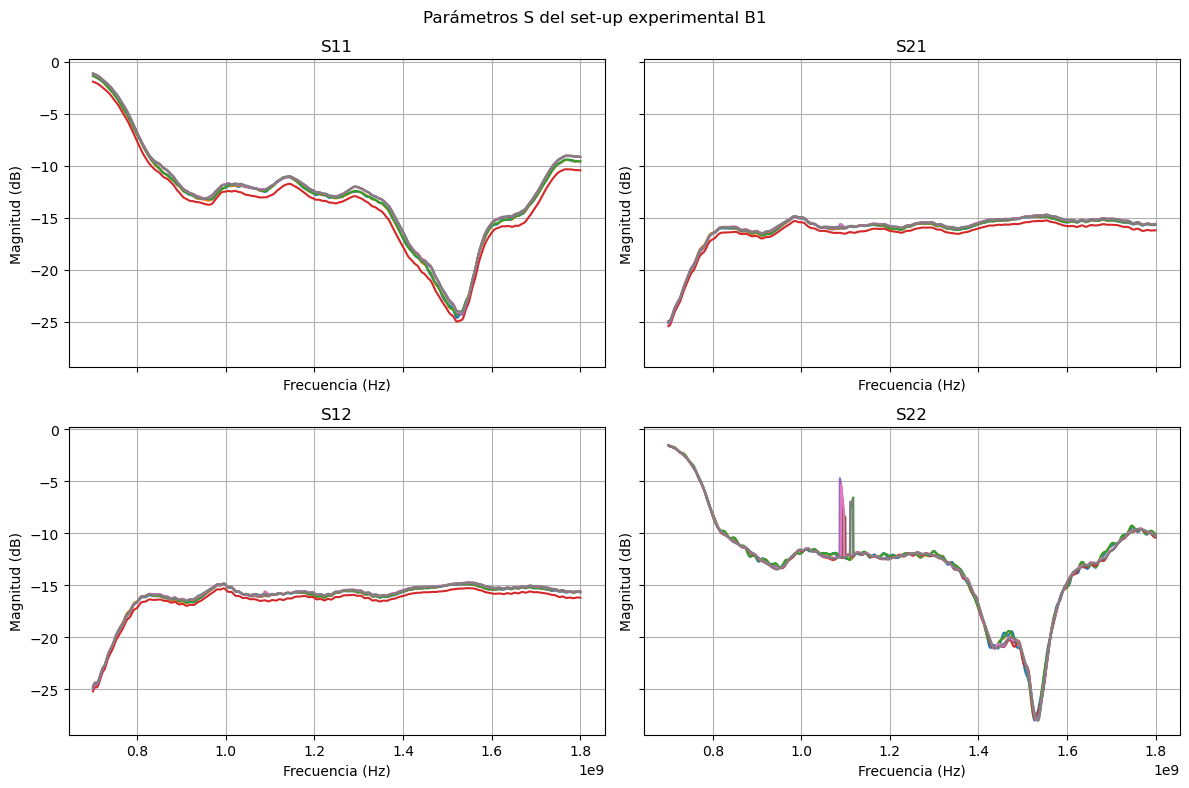

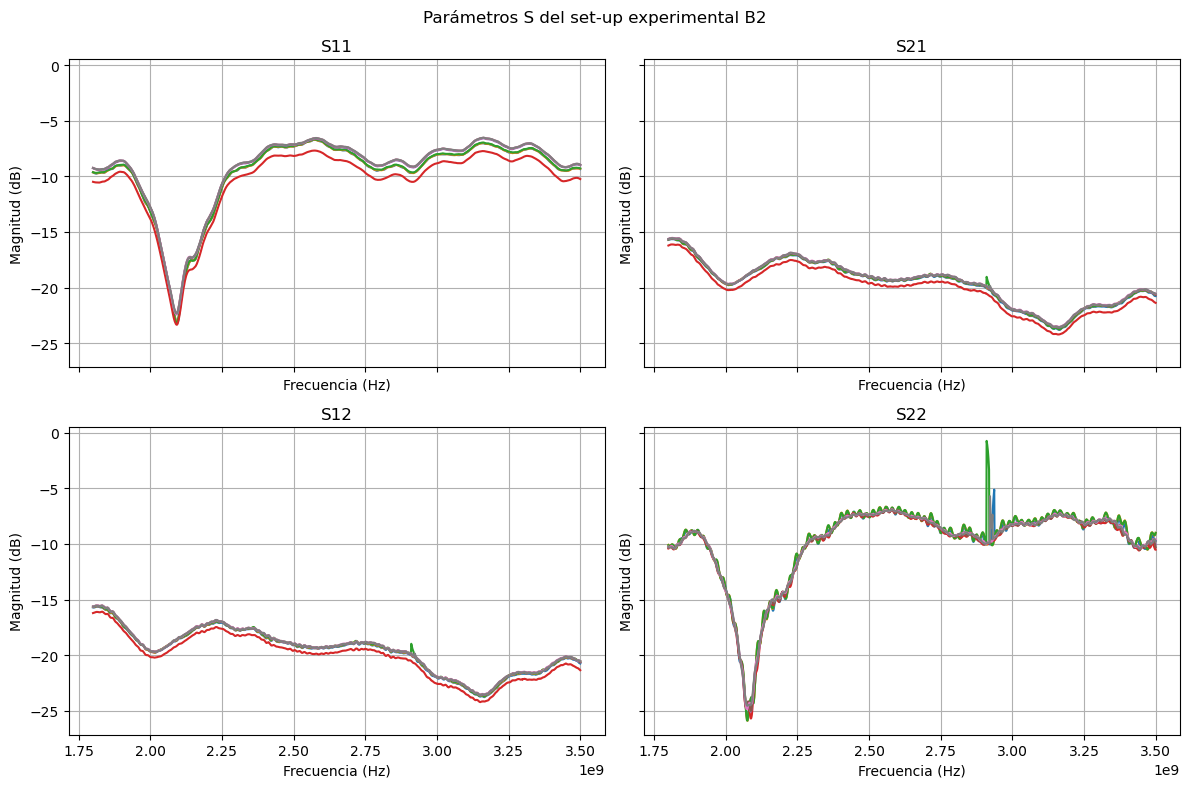

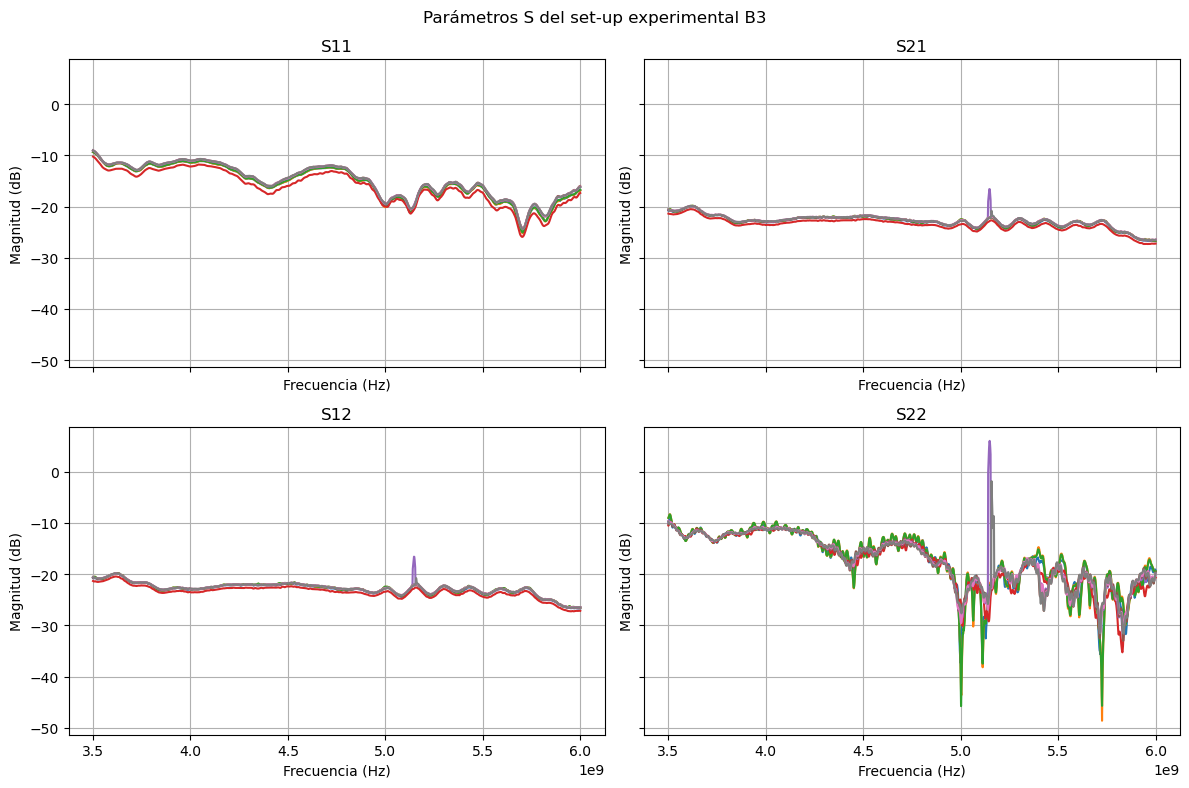

In [8]:
data_dir = Path('./data/air_check')
networks = load_networks(data_dir)
print(networks.keys())
grouped_networks = group_networks_by_band(networks)
fig_b1 = plot_s_parameters_sameplot(grouped_networks['B1'], title='Parámetros S del set-up experimental B1')
fig_b2 = plot_s_parameters_sameplot(grouped_networks['B2'], title='Parámetros S del set-up experimental B2')
fig_b3 = plot_s_parameters_sameplot(grouped_networks['B3'], title='Parámetros S del set-up experimental B3')

Se observa consistencia entre las medidas del sistema —sin el aguacate— realizadas a lo largo de los días para las tres bandas experimentales.

Ahora revisirimos la repetitibilidad del sistema al colocar dos veces el mismo aguacate. Para ello se colocó el aguacate A01 en el set-up experimental y se tomó la medida. Luego se recolocó el aguacate en la misma posición y se volvío a tomar la medida. Se gráfican ambos resultados con el objeto de hacer comparaciones.

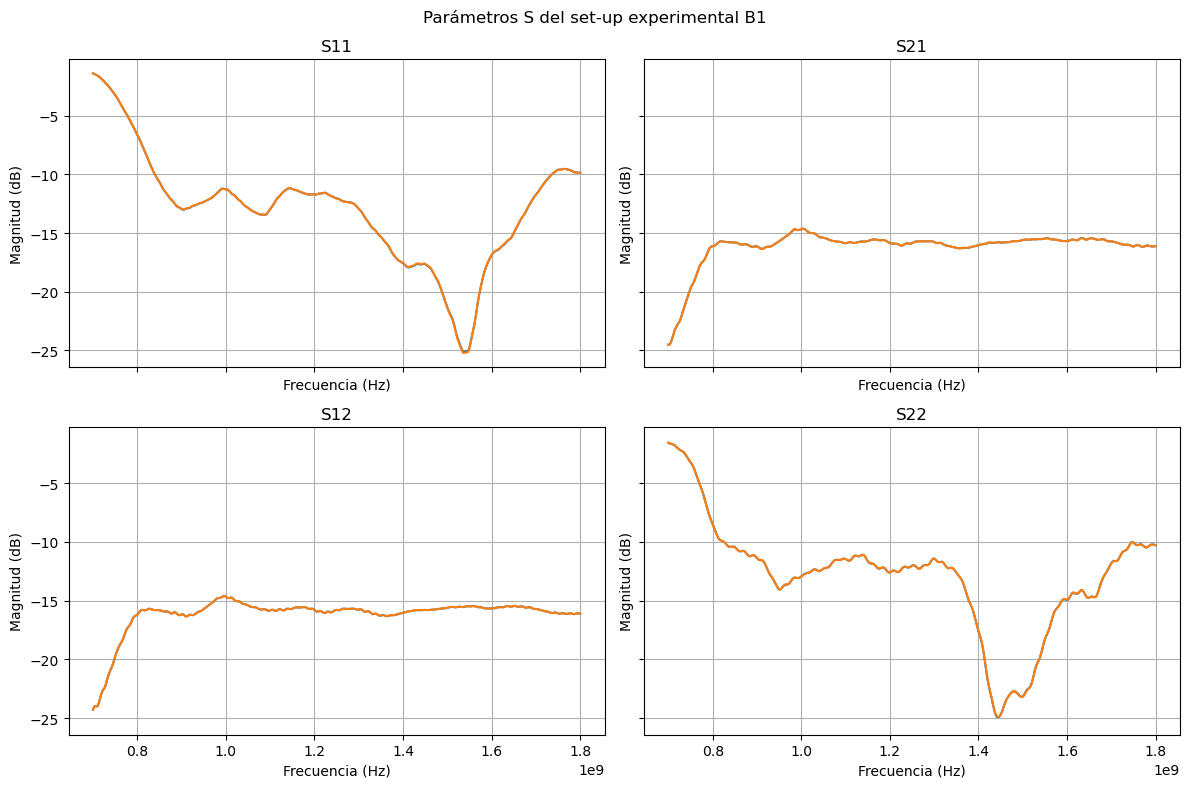

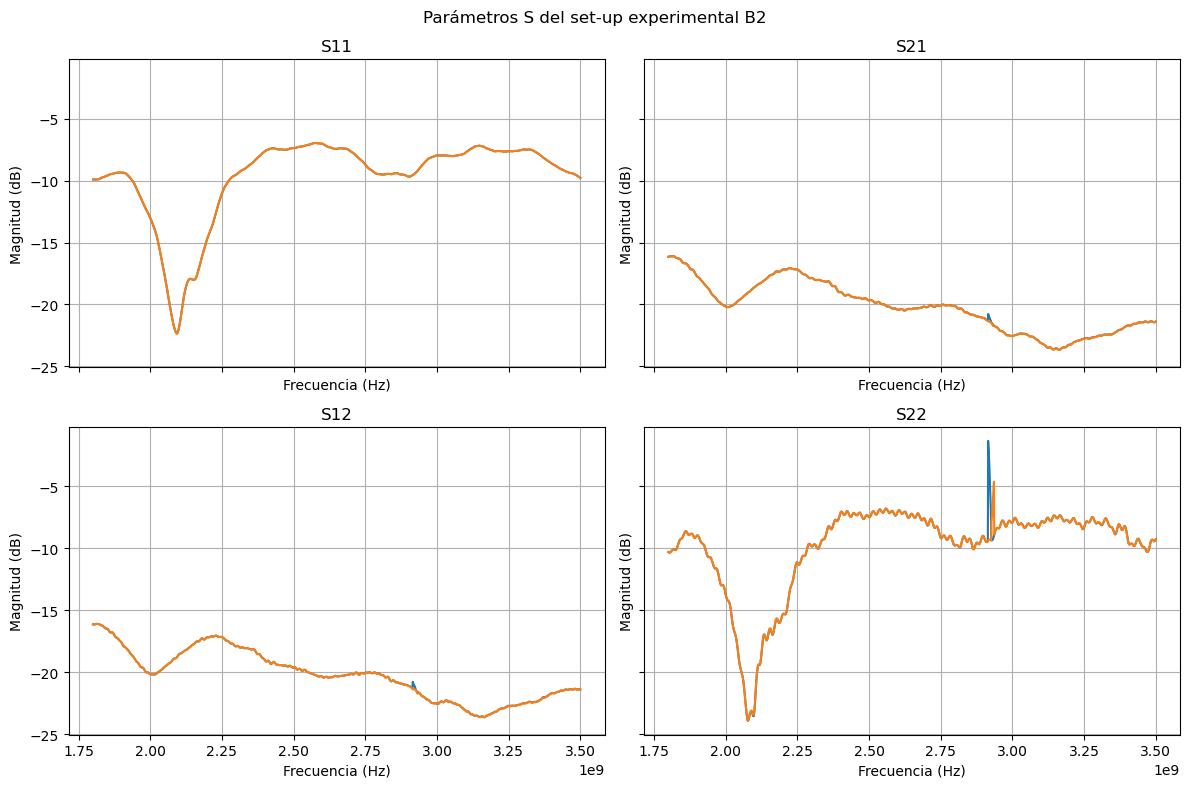

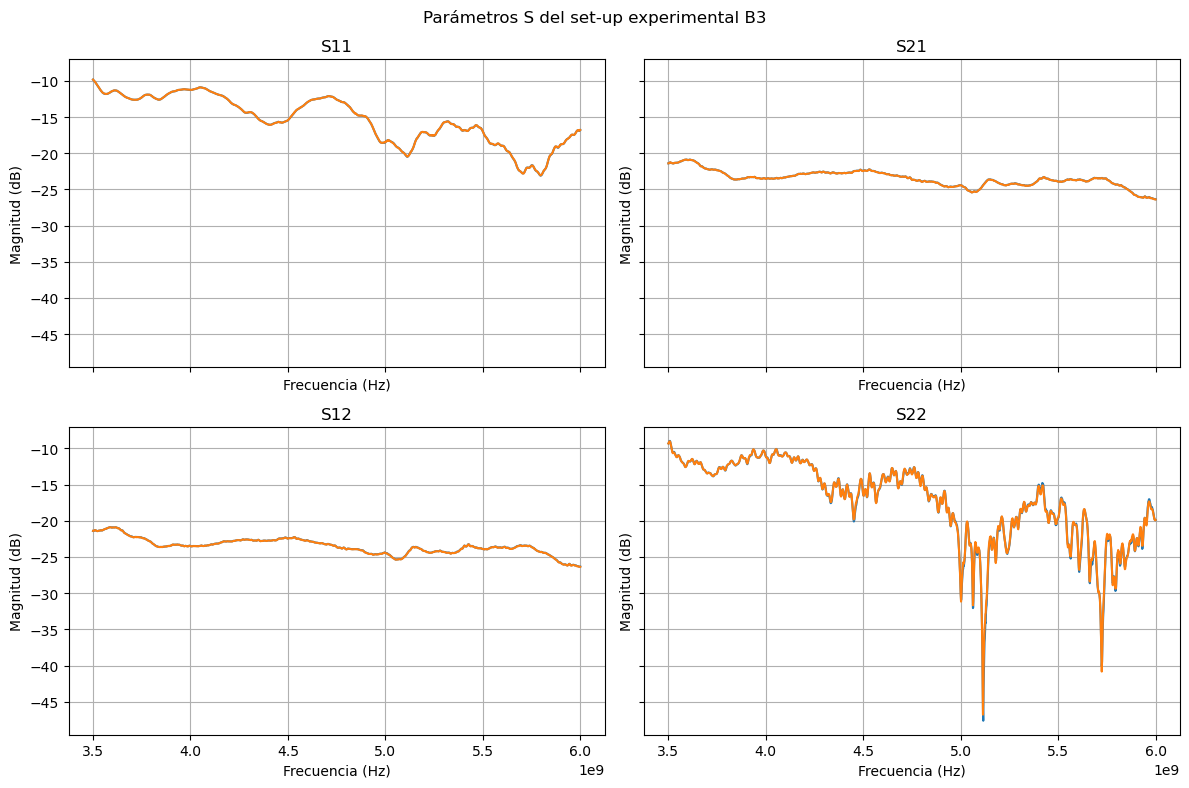

In [9]:
data_dir = Path('./data/avocado_check')
networks = load_networks(data_dir)
grouped_networks = group_networks_by_band(networks)
fig_b1 = plot_s_parameters_sameplot(grouped_networks['B1'], title='Parámetros S del set-up experimental B1')
fig_b2 = plot_s_parameters_sameplot(grouped_networks['B2'], title='Parámetros S del set-up experimental B2')
fig_b3 = plot_s_parameters_sameplot(grouped_networks['B3'], title='Parámetros S del set-up experimental B3')

Se observa consistencia entre las diferentes medidas del sistema de medida. Sin embargo, se detecta una interferencia en el sistema alrededor de ciertos valores de frecuencia (**B2**). Se decidirá como tratar estos datos más adelante.

Finalmente, observemos como se observa la medida de un mismo aguacate (A08) a lo largo de diferentes estados de maduración y en sus distintas posiciones de medida. 
Los parámetros S medidos son números complejos, por lo cuál se gráfica su magnitud, parte real, parte imaginaria y fase para usarlos como comparativos y explorar la posibilidad de que aporten información discriminativa a la señal:

Magnitud de los párametros de dispersión:

dict_keys(['A08_D01_B1_O000_corrected', 'A08_D01_B1_O120_corrected', 'A08_D01_B1_O240_corrected', 'A08_D01_B2_O000_corrected', 'A08_D01_B2_O120_corrected', 'A08_D01_B2_O240_corrected', 'A08_D01_B3_O000_corrected', 'A08_D01_B3_O120_corrected', 'A08_D01_B3_O240_corrected', 'A08_D02_B1_O000_corrected', 'A08_D02_B1_O120_corrected', 'A08_D02_B1_O240_corrected', 'A08_D02_B2_O000_corrected', 'A08_D02_B2_O120_corrected', 'A08_D02_B2_O240_corrected', 'A08_D02_B3_O000_corrected', 'A08_D02_B3_O120_corrected', 'A08_D02_B3_O240_corrected', 'A08_D03_B1_O000_corrected', 'A08_D03_B1_O120_corrected', 'A08_D03_B1_O240_corrected', 'A08_D03_B2_O000_corrected', 'A08_D03_B2_O120_corrected', 'A08_D03_B2_O240_corrected', 'A08_D03_B3_O000_corrected', 'A08_D03_B3_O120_corrected', 'A08_D03_B3_O240_corrected', 'A08_D04_B1_O000_corrected', 'A08_D04_B1_O120_corrected', 'A08_D04_B1_O240_corrected', 'A08_D04_B2_O000_corrected', 'A08_D04_B2_O120_corrected', 'A08_D04_B2_O240_corrected', 'A08_D04_B3_O000_corrected', 'A0

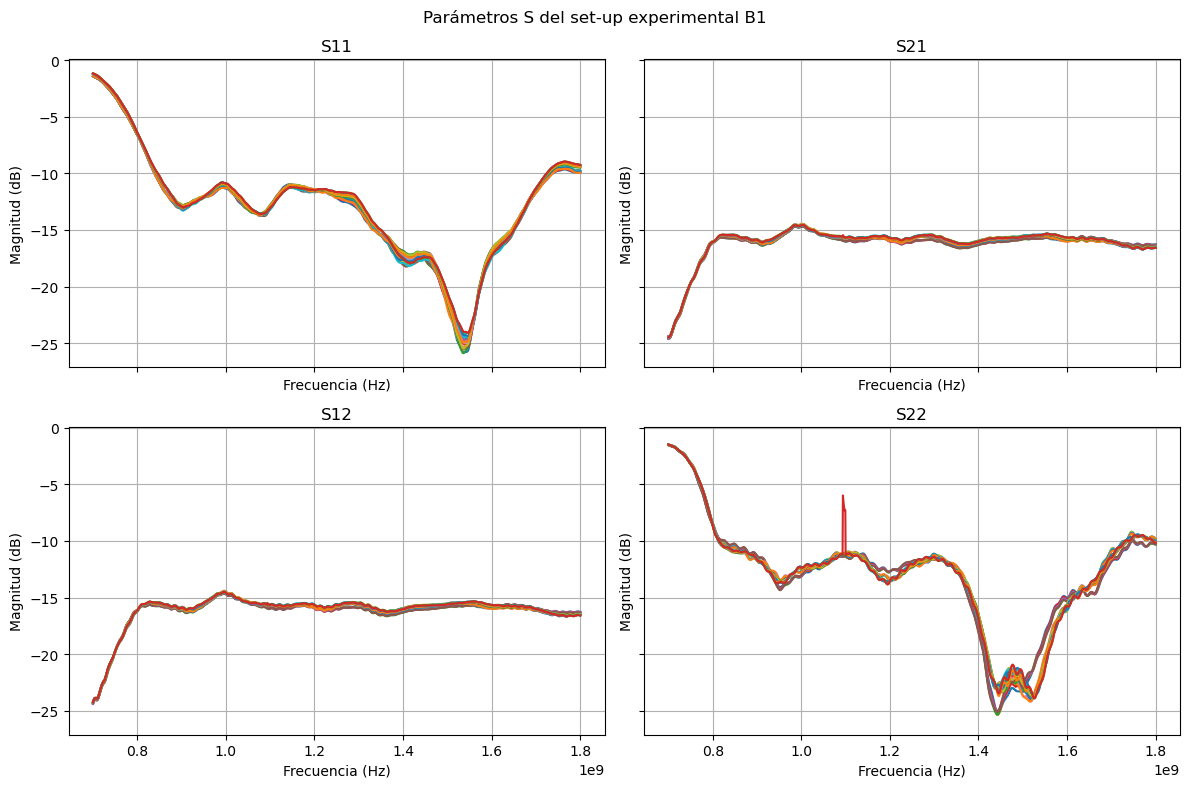

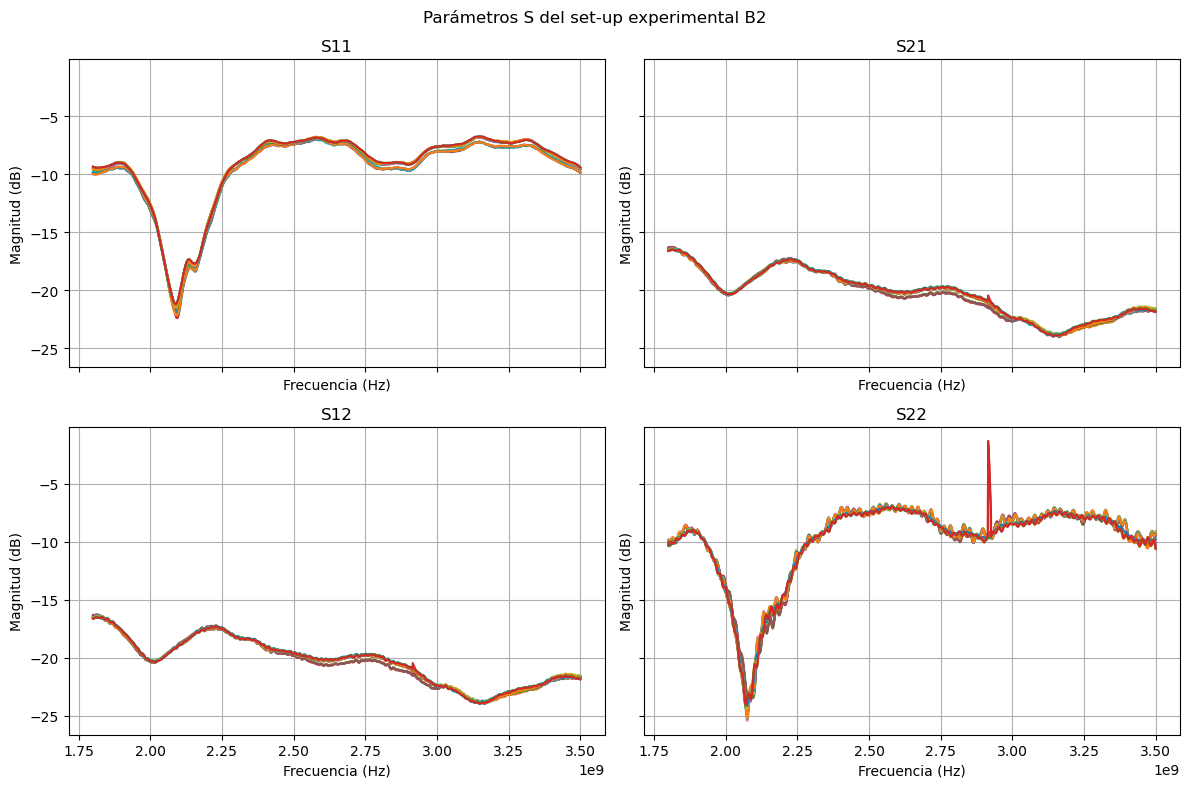

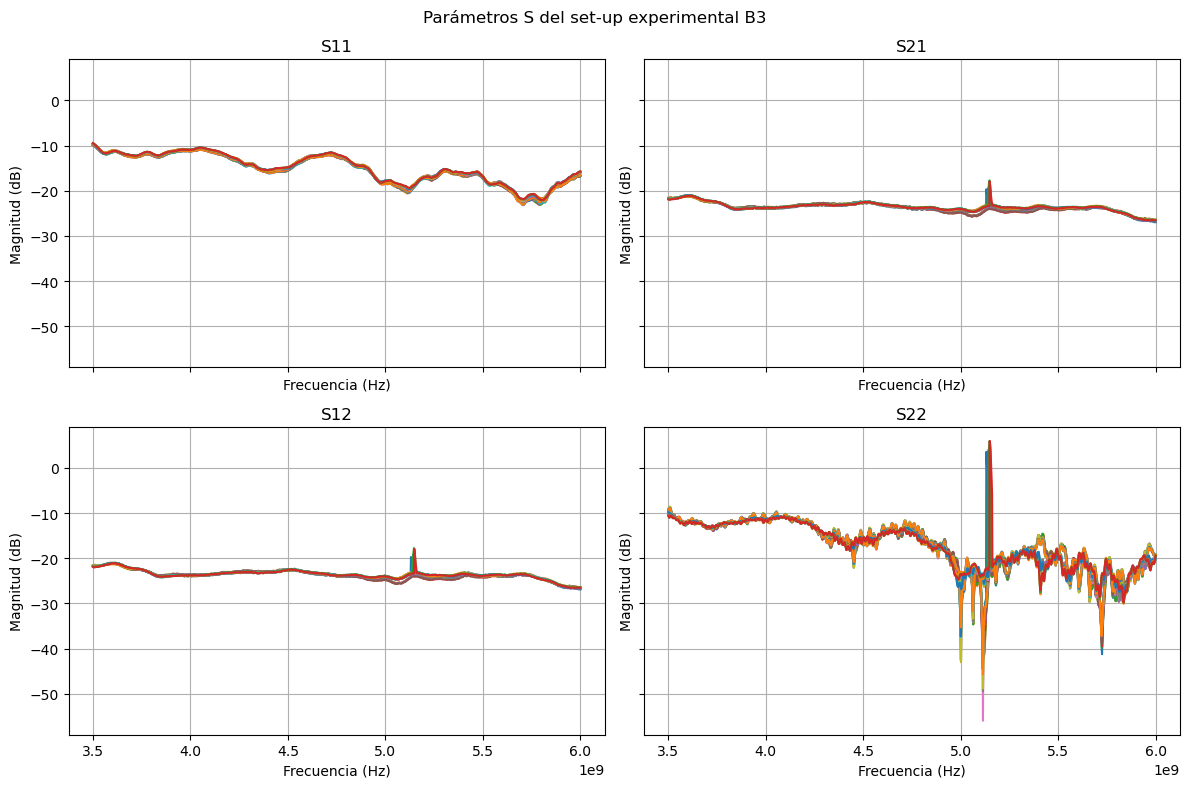

In [10]:
data_dir = Path('./data/avocado_time_check')
networks = load_networks(data_dir)
print(networks.keys())
grouped_networks = group_networks_by_band(networks)
fig_b1 = plot_s_parameters_sameplot(grouped_networks['B1'], title='Parámetros S del set-up experimental B1',show_legend = False)
fig_b2 = plot_s_parameters_sameplot(grouped_networks['B2'], title='Parámetros S del set-up experimental B2',show_legend = False)
fig_b3 = plot_s_parameters_sameplot(grouped_networks['B3'], title='Parámetros S del set-up experimental B3',show_legend = False)

Parte real e imaginaria de los parámetros de dispersión

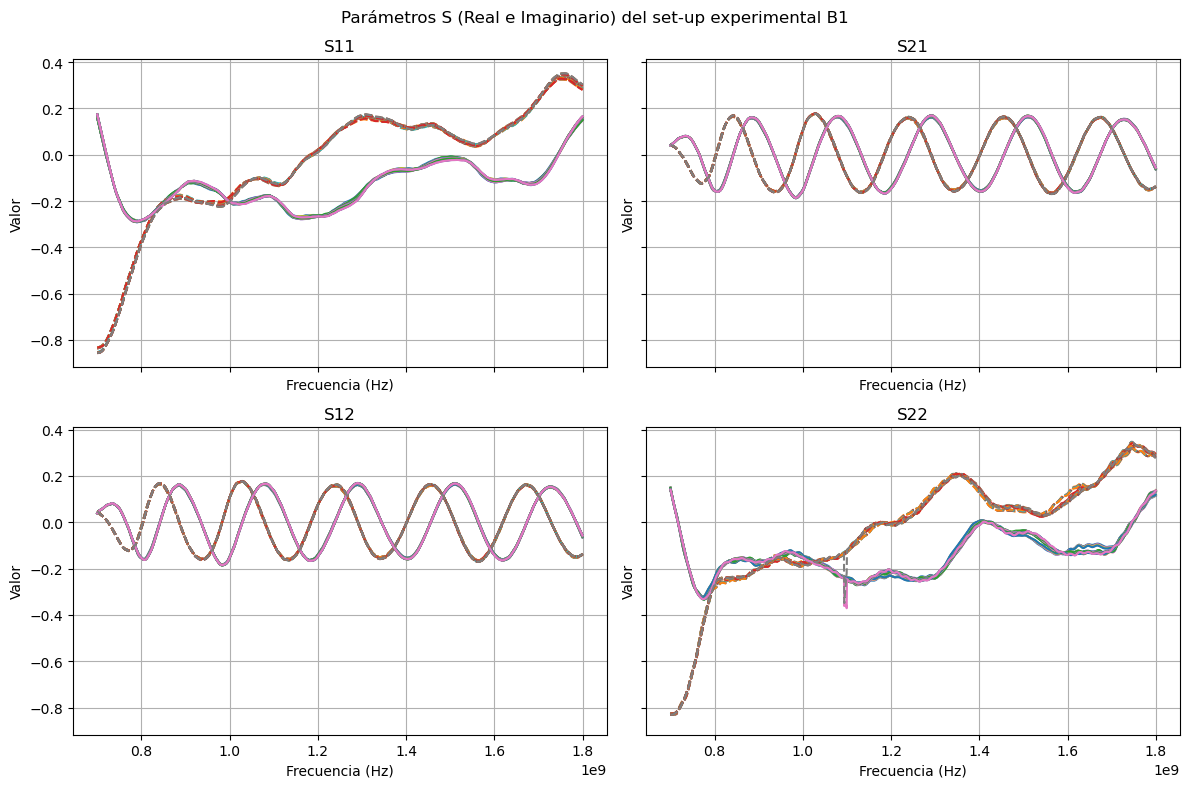

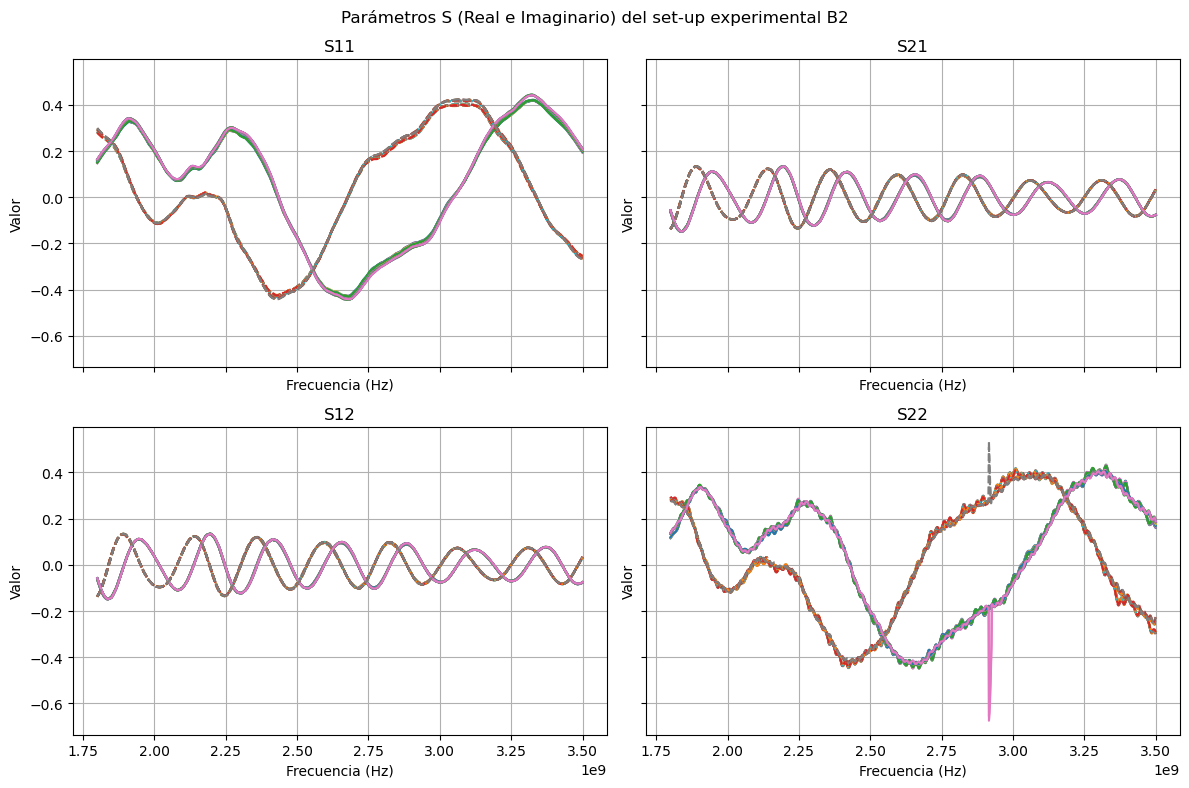

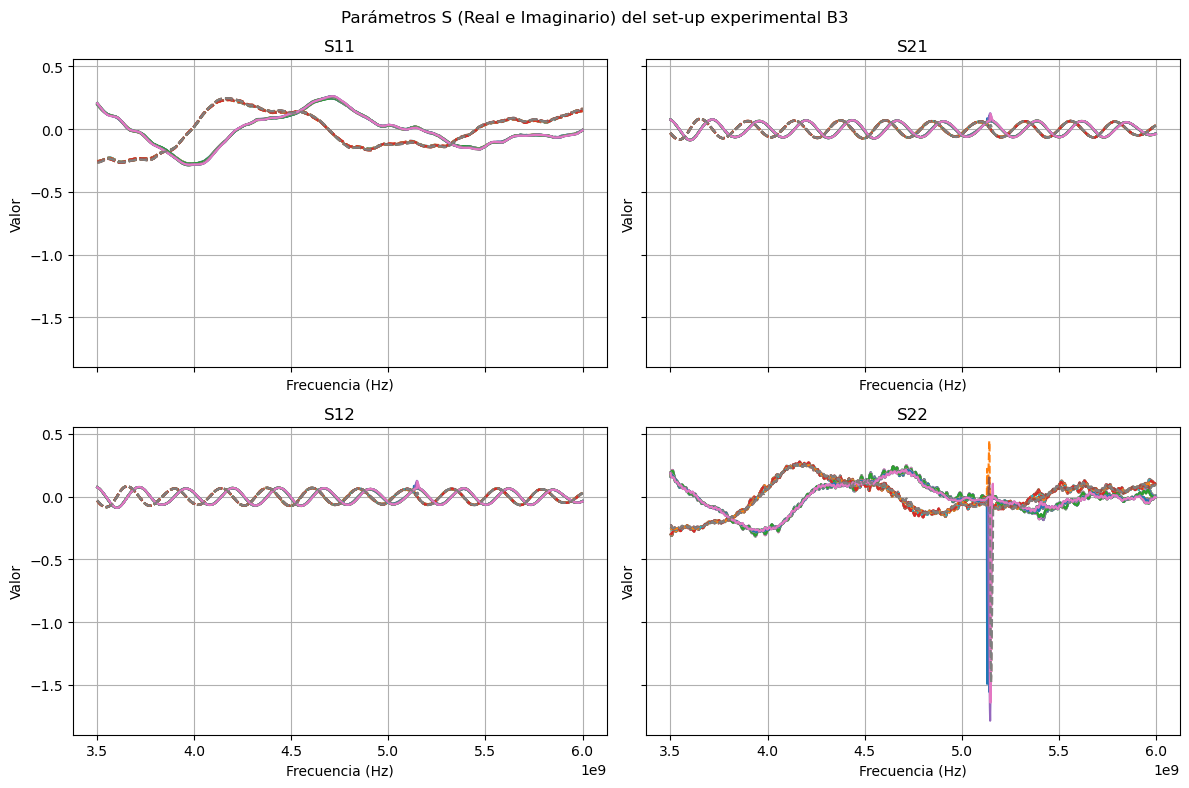

In [11]:
fig_b1_ri = plot_s_parameters_real_and_imag(grouped_networks['B1'], title='Parámetros S (Real e Imaginario) del set-up experimental B1', show_legend = False)
fig_b2_ri = plot_s_parameters_real_and_imag(grouped_networks['B2'], title='Parámetros S (Real e Imaginario) del set-up experimental B2', show_legend = False)
fig_b3_ri = plot_s_parameters_real_and_imag(grouped_networks['B3'], title='Parámetros S (Real e Imaginario) del set-up experimental B3', show_legend = False)

Fase de los parámetros de dispersión

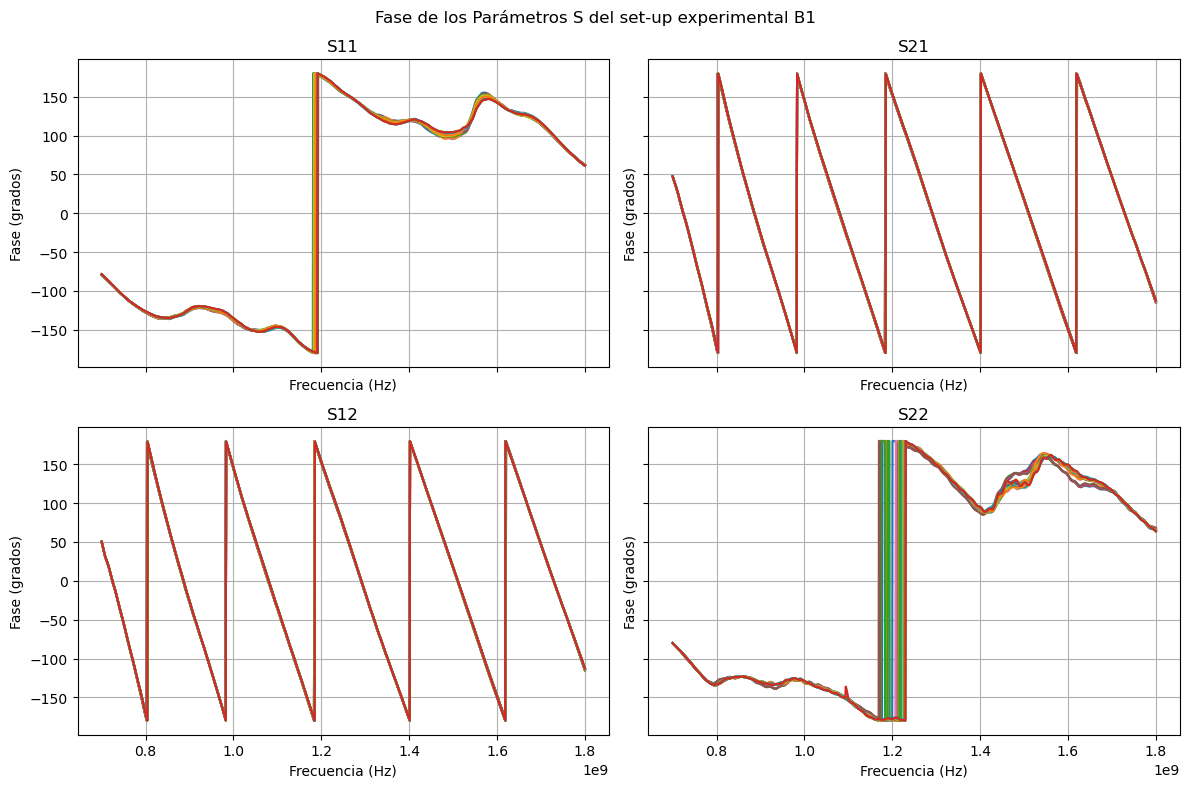

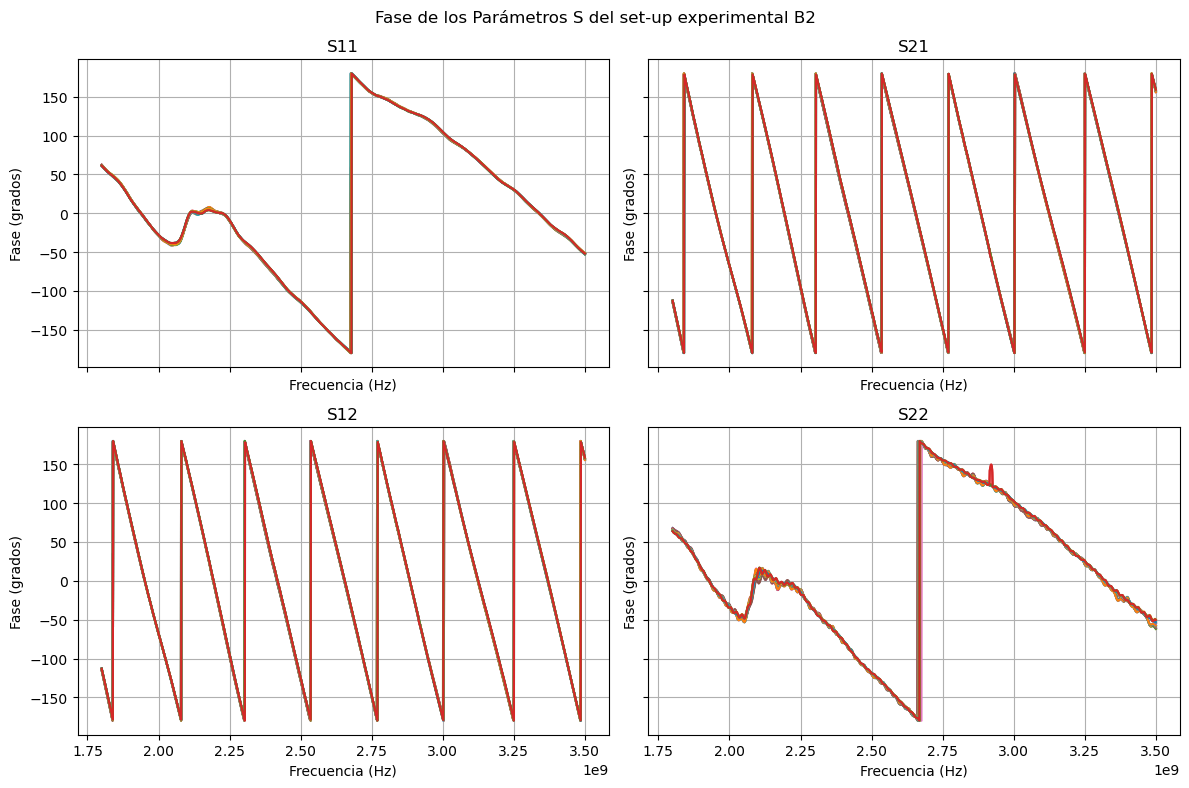

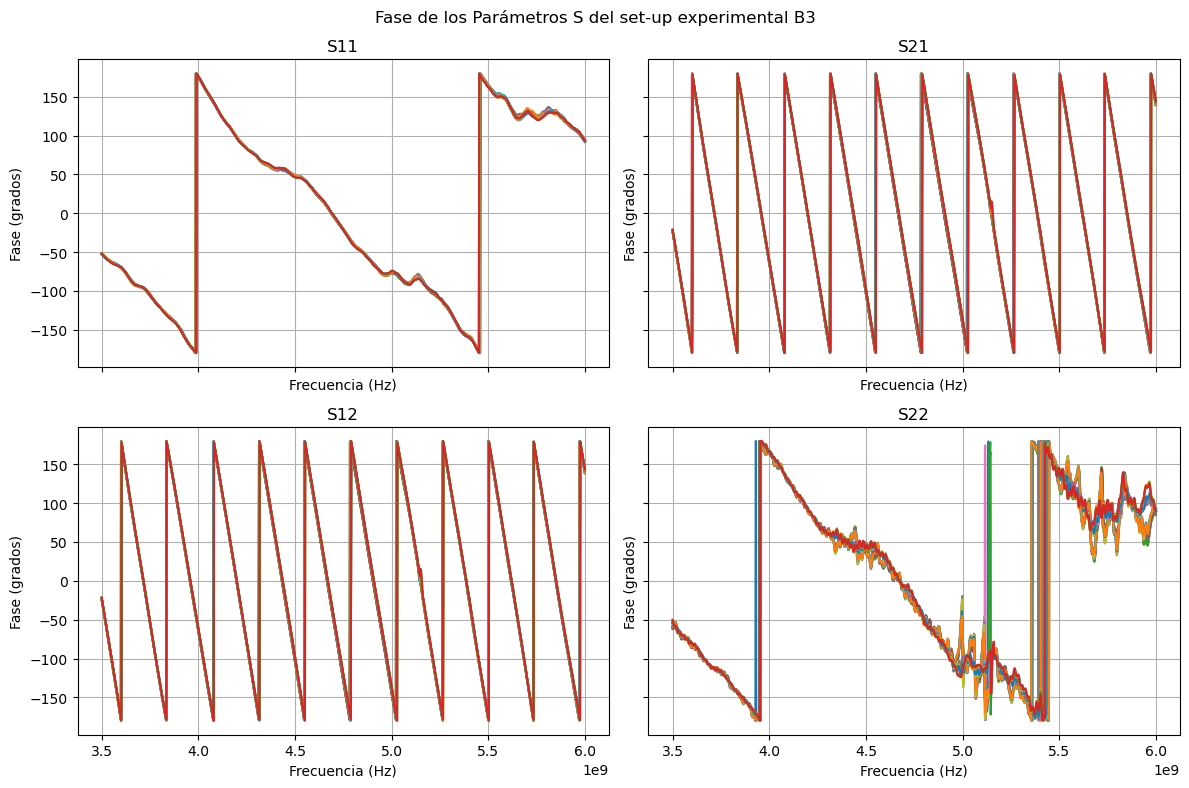

In [12]:
fig_b1_phase = plot_s_parameters_phase(grouped_networks['B1'], title='Fase de los Parámetros S del set-up experimental B1')
fig_b2_phase = plot_s_parameters_phase(grouped_networks['B2'], title='Fase de los Parámetros S del set-up experimental B2')
fig_b3_phase = plot_s_parameters_phase(grouped_networks['B3'], title='Fase de los Parámetros S del set-up experimental B3') 

No se observan diferencias significativas en la magnitud, parte real e imaginaria de los parámetros de dispersión del mismo aguacate entre distintos días de medición, pese a cambios en su posición dentro del sistema experimental. Esto sugiere que el efecto del acoplamiento antena–muestra domina sobre los posibles cambios internos del fruto. En contraste, la fase de los parámetros de reflexión presenta ligeras variaciones entre mediciones; sin embargo, estas pueden estar influenciadas tanto por cambios en las propiedades del aguacate como por variaciones en su posicionamiento. En conjunto, esto puede limitar la capacidad del modelo para separar adecuadamente los estados de maduración.

Haré una normalización del dataset. La normalización consiste en dividir los parámetros S de la muestra de aguacate entre los parámetros S de la muestra sin aguacate. 

$$ S_{sample,norm} = \frac{S_{sample}}{S_{air}} $$

Graficaré todas mis muestras para buscar tendencias en los datos y observar dónde puedo encontrar señal útil.

#### Carga del dataset completo y normalización

Generó un diccionario con datos normalizados, como el día D01 no se midió el *baseline* (sistema sin muestra), por lo cuál tomó la decisión de descartar esos datos..

In [13]:
data_dir_all = Path('./data')
networks_all = load_networks(data_dir_all)

In [14]:
def normalize_dataset_by_air(
    networks,
    use_newcal_from_sample24_day04=False,  # Si True, usa AIR_NewCal desde A24 y D04 en adelante.
    discard_days=None,
):
    """
    Normaliza todas las muestras del dataset usando los AIR presentes en el mismo diccionario.

    Regla esperada:
    sample: A08_D02_B1_O000_corrected
    air:    AIR_D02_B1_corrected

    Regla opcional NewCal:
    - Desde sample_code >= A24
    - y day_code >= D04
    se usa AIR_Dxx_NewCal_Bx_corrected (si existe).
    """

    if discard_days is None:
        discard_days = {'D01'}  # D01 no se midio baseline, por lo que se descarta completamente.

    def _to_int_code(code, prefix):
        if code is None or not isinstance(code, str):
            return None
        if not code.startswith(prefix):
            return None
        digits = ''.join(ch for ch in code if ch.isdigit())
        if not digits:
            return None
        return int(digits)

    normalized = {}
    missing_air = []
    discarded = 0
    skipped_air = 0
    used_newcal = 0

    for sample_key, ntwk_sample in networks.items():  # AIR no se normalizan.
        parsed = parse_key(sample_key)

        if parsed['is_air']:
            skipped_air += 1
            continue

        if parsed['sample_code'] is None:
            continue

        day = parsed['day_code']
        band = parsed['band']

        if day is None or band is None:
            missing_air.append((sample_key, 'formato_invalido'))
            continue

        if day in discard_days:
            discarded += 1
            continue

        sample_num = _to_int_code(parsed['sample_code'], 'A')
        day_num = _to_int_code(day, 'D')

        use_newcal_this_sample = (
            use_newcal_from_sample24_day04
            and sample_num is not None and sample_num >= 24
            and day_num is not None and day_num >= 4
        )

        if use_newcal_this_sample:
            air_key = f"AIR_{day}_NewCal_{band}_corrected"
            if air_key in networks:
                used_newcal += 1
            else:
                # Fallback al AIR original si no existe NewCal para ese dia/banda.
                air_key = f"AIR_{day}_{band}_corrected"
        else:
            air_key = f"AIR_{day}_{band}_corrected"

        if air_key not in networks:
            missing_air.append((sample_key, air_key))
            continue

        ntwk_corr = ntwk_sample.copy()
        ntwk_corr.s = ntwk_sample.s / networks[air_key].s
        normalized[sample_key] = ntwk_corr

    print(f"AIR omitidos: {skipped_air}")
    print(f"Descartadas por dia: {discarded}")
    print(f"Normalizadas: {len(normalized)}")
    print(f"Normalizadas con NewCal: {used_newcal}")
    print(f"Sin AIR: {len(missing_air)}")
    if missing_air:
        print('Ejemplos faltantes:', missing_air[:5])

    return normalized, missing_air

Grafico algunas muestras de los parámetros normalizados para evaluar si la normalización mejoró la distinción inter-clase e inter-sujeto:

AIR omitidos: 24
Descartadas por dia: 315
Normalizadas: 2961
Normalizadas con NewCal: 225
Sin AIR: 0
B1: mostrando 30 de 987 trazas normalizadas
B2: mostrando 30 de 987 trazas normalizadas
B3: mostrando 30 de 987 trazas normalizadas


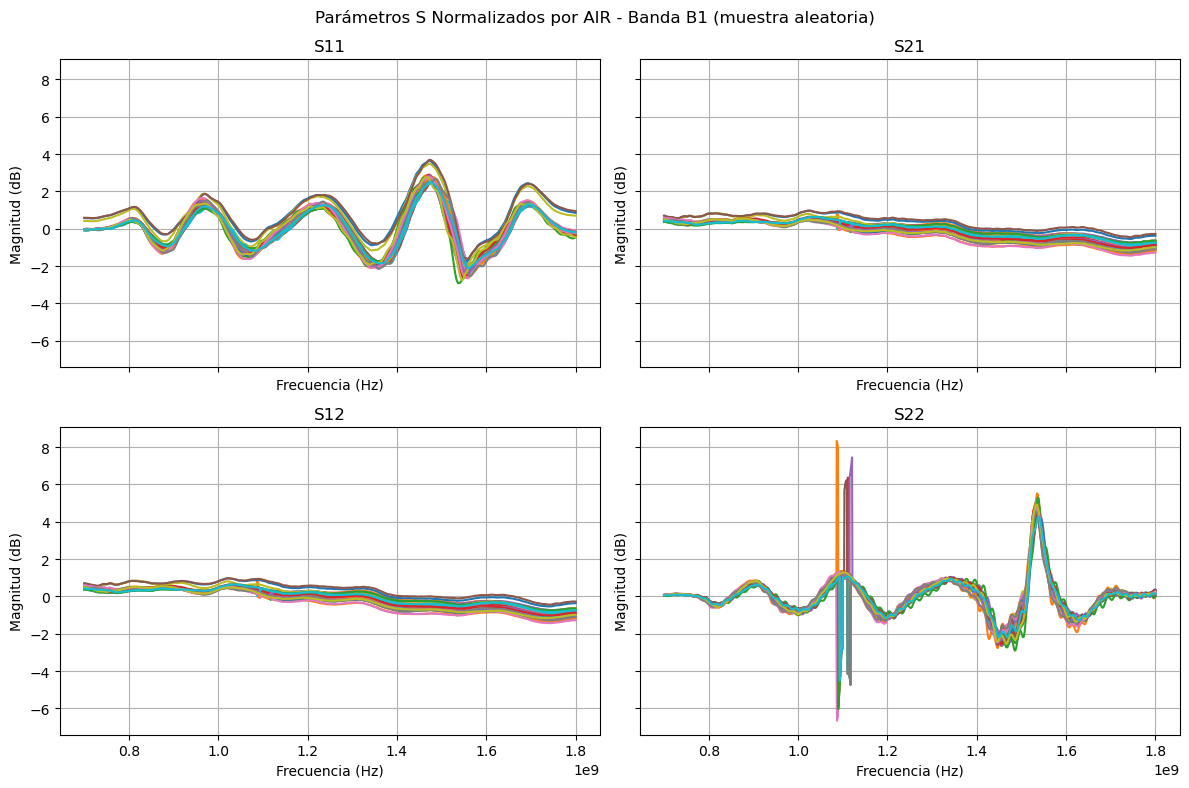

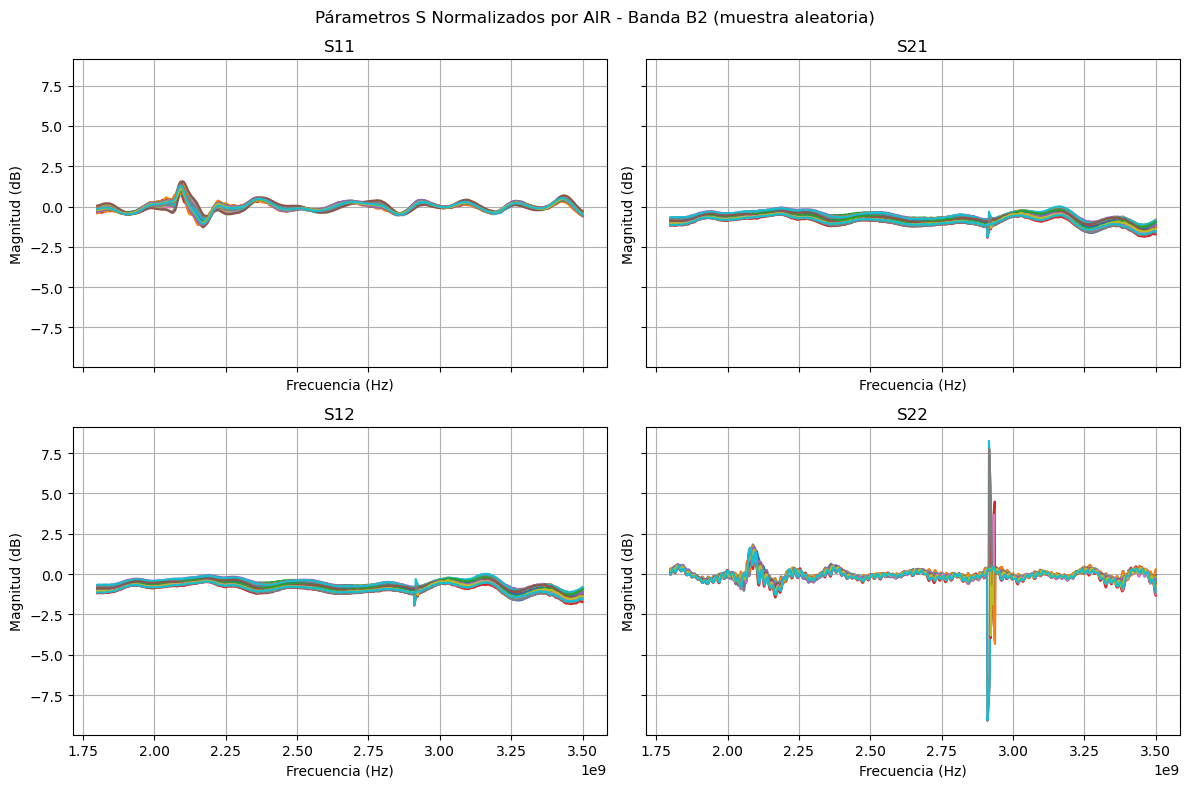

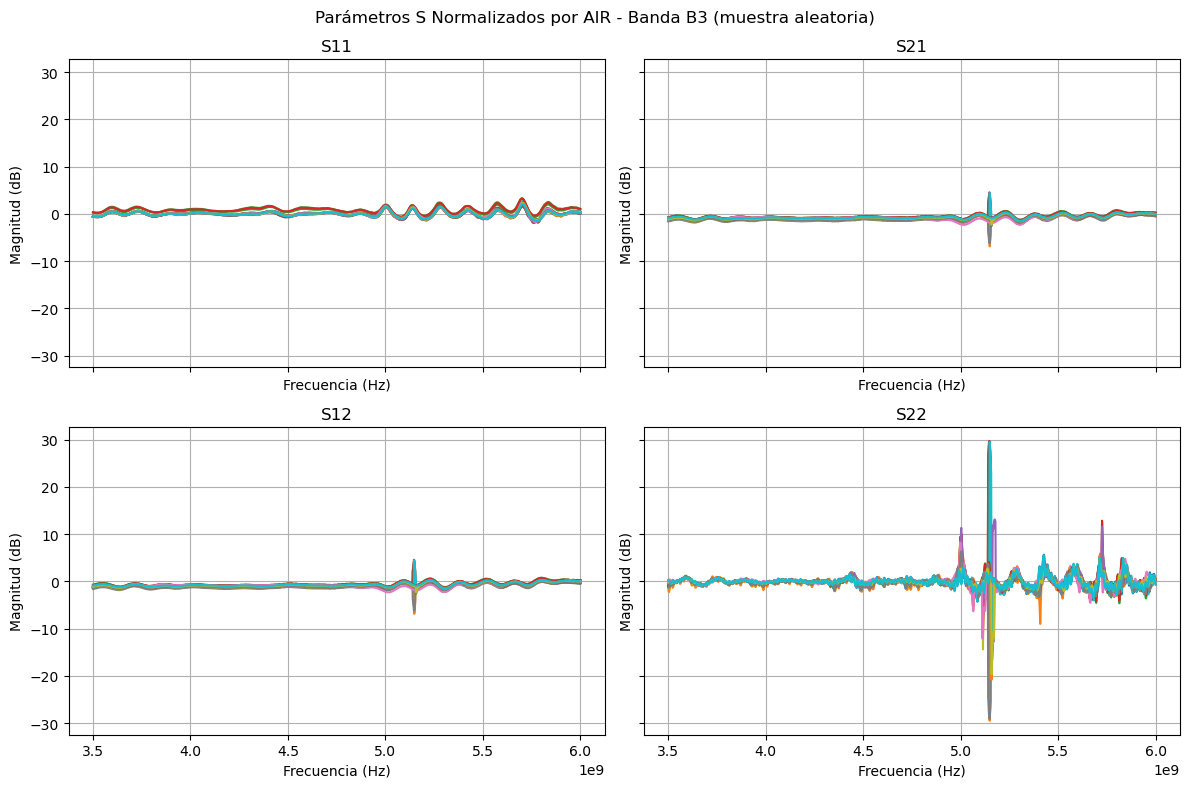

In [15]:
normalized = normalize_dataset_by_air(networks_all, use_newcal_from_sample24_day04=True)[0]
grouped_networks = group_networks_by_band(normalized)

rng = np.random.default_rng(123)
n_por_banda = 30  # Muestra moderada para graficar

sampled_grouped = {}
for band in ('B1', 'B2', 'B3'):
    keys = list(grouped_networks[band].keys())
    if not keys:
        sampled_grouped[band] = {}
        continue

    n = min(n_por_banda, len(keys))
    selected = list(rng.choice(keys, size=n, replace=False))
    sampled_grouped[band] = {k: grouped_networks[band][k] for k in selected}
    print(f'{band}: mostrando {n} de {len(keys)} trazas normalizadas')

fig_nb1 = plot_s_parameters_sameplot(sampled_grouped['B1'], title='Parámetros S Normalizados por AIR - Banda B1 (muestra aleatoria)', show_legend=False)
fig_b2 = plot_s_parameters_sameplot(sampled_grouped['B2'], title='Párametros S Normalizados por AIR - Banda B2 (muestra aleatoria)', show_legend=False)
fig_b3 = plot_s_parameters_sameplot(sampled_grouped['B3'], title='Parámetros S Normalizados por AIR - Banda B3 (muestra aleatoria)', show_legend=False)

Antes de continuar con la exploración de datos, se realizó un proceso de limpieza en los rangos de frecuencia donde se identificaron interferencias propias del sistema, con el objetivo de evitar la introducción de ruido en el modelo.

Esta limpieza consistió en identificar los intervalos de frecuencia afectados por artefactos y conservar dichas frecuencias dentro del conjunto de datos, pero reemplazando los valores de los parámetros medidos por valores nulos (NaN). De esta forma, se preserva la estructura espectral original sin incorporar información distorsionada en el análisis posterior.

In [16]:
def mask_interference_ranges(
    networks,
    ranges_by_band_ghz=None,
    include_air=False,
):
    """
    Enmascara (NaN) rangos de frecuencia con interferencia por banda.

    Los rangos se definen en GHz y se aplican por banda (B1/B2/B3).
    """
    if ranges_by_band_ghz is None:
        ranges_by_band_ghz = {
            'B1': [(1.05, 1.2)],
            'B2': [(2.8, 3.2)],
            'B3': [(4.95, 5.4)],
        }

    cleaned = {}
    total_masked_points = 0
    traces_with_mask = 0

    for key, ntwk in networks.items():
        parsed = parse_key(key)
        band = parsed['band']

        if parsed['is_air'] and not include_air:
            cleaned[key] = ntwk
            continue

        ntwk_clean = ntwk.copy()
        band_ranges = ranges_by_band_ghz.get(band, [])

        if not band_ranges:
            cleaned[key] = ntwk_clean
            continue

        f_ghz = np.asarray(ntwk_clean.f, dtype=float) / 1e9
        mask = np.zeros_like(f_ghz, dtype=bool)
        for f_min, f_max in band_ranges:
            mask |= (f_ghz >= f_min) & (f_ghz <= f_max)

        if np.any(mask):
            s = ntwk_clean.s.copy()
            s[mask, :, :] = np.nan + 1j * np.nan
            ntwk_clean.s = s
            traces_with_mask += 1
            total_masked_points += int(np.sum(mask))

        cleaned[key] = ntwk_clean

    print(f'Trazas con interferencia enmascarada: {traces_with_mask}')
    print(f'Total de puntos de frecuencia enmascarados: {total_masked_points}')
    return cleaned
networks_norm, missing_air = normalize_dataset_by_air(
    networks_all,
    use_newcal_from_sample24_day04=True,
    discard_days={'D01'},
)
print(list(networks_norm.keys())[:5])


AIR omitidos: 24
Descartadas por dia: 315
Normalizadas: 2961
Normalizadas con NewCal: 225
Sin AIR: 0
['A01_D02_B1_O000_corrected', 'A01_D02_B1_O120_corrected', 'A01_D02_B1_O240_corrected', 'A01_D02_B2_O000_corrected', 'A01_D02_B2_O120_corrected']


In [17]:
# Limpieza de interferencias
networks_clean = mask_interference_ranges(networks_norm)
print('Networks limpias:', len(networks_clean))

Trazas con interferencia enmascarada: 2961
Total de puntos de frecuencia enmascarados: 871521
Networks limpias: 2961


Se gráfican las muestras limpias para verificar que el resultado sea satisfactorio:

B1: mostrando 8 de 987 muestras limpias
B2: mostrando 8 de 987 muestras limpias
B3: mostrando 8 de 987 muestras limpias


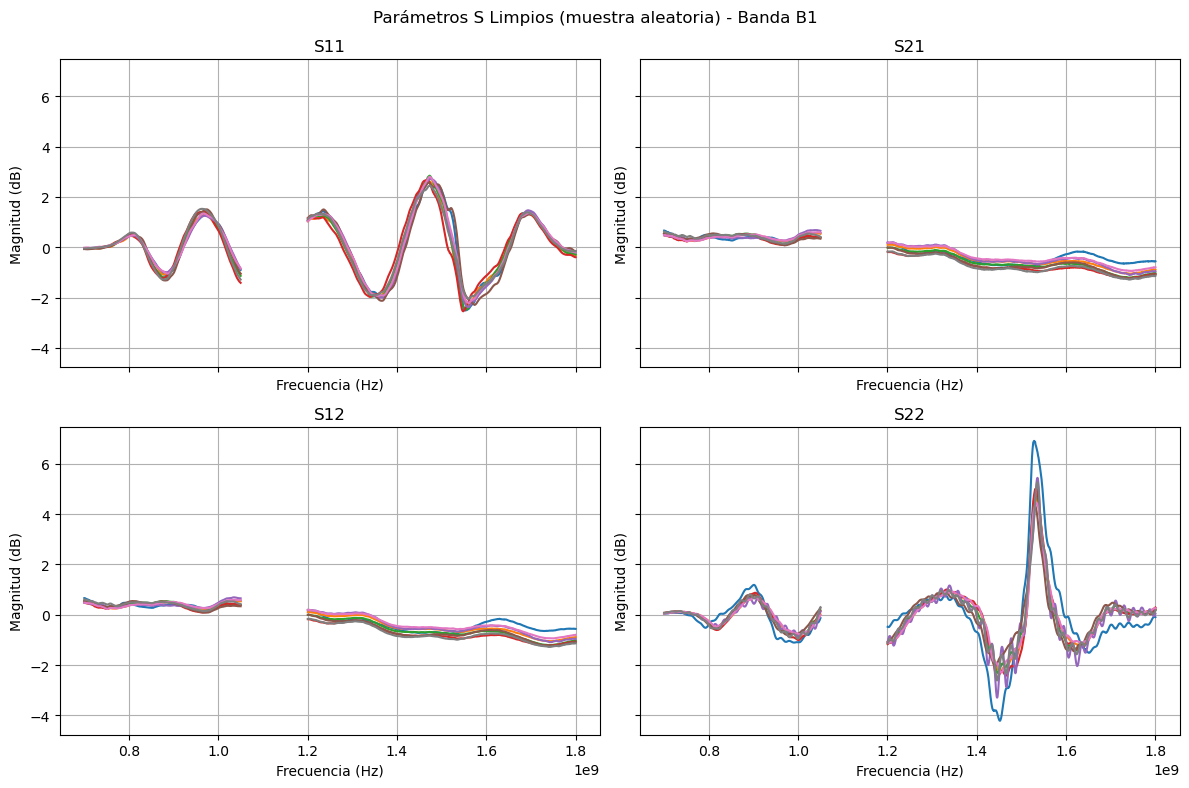

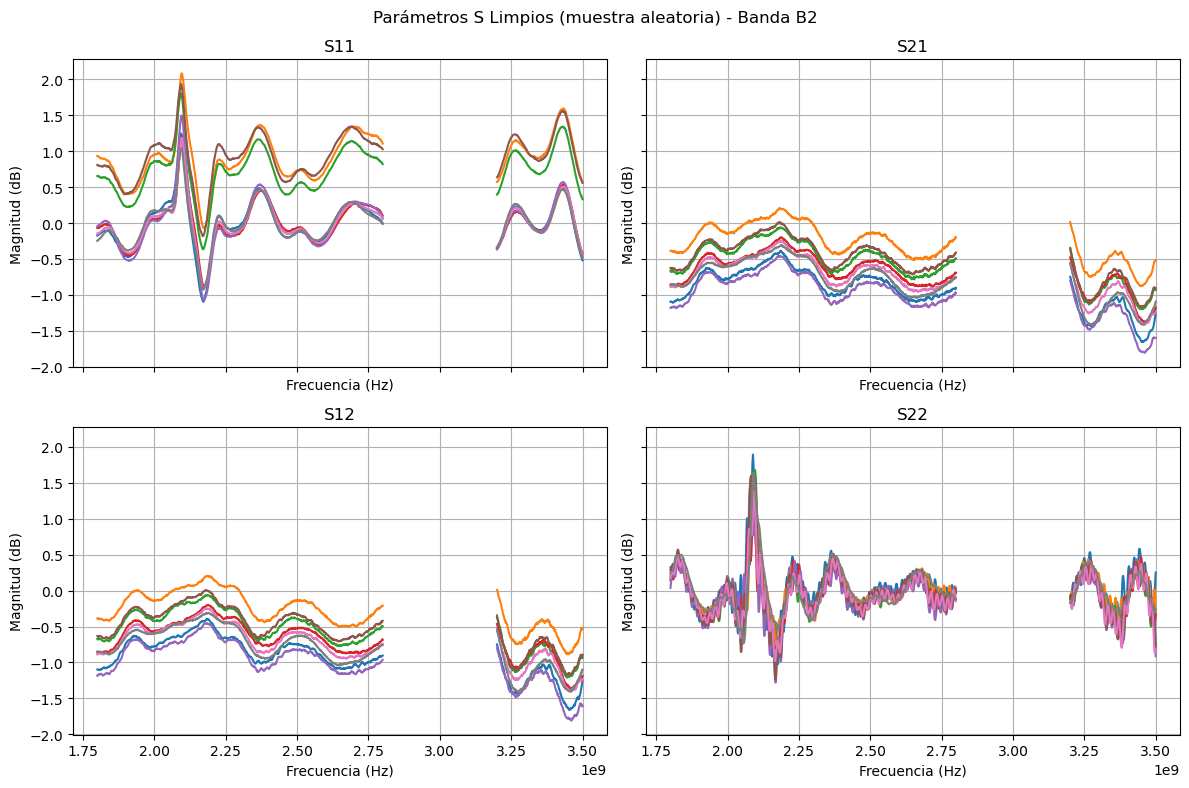

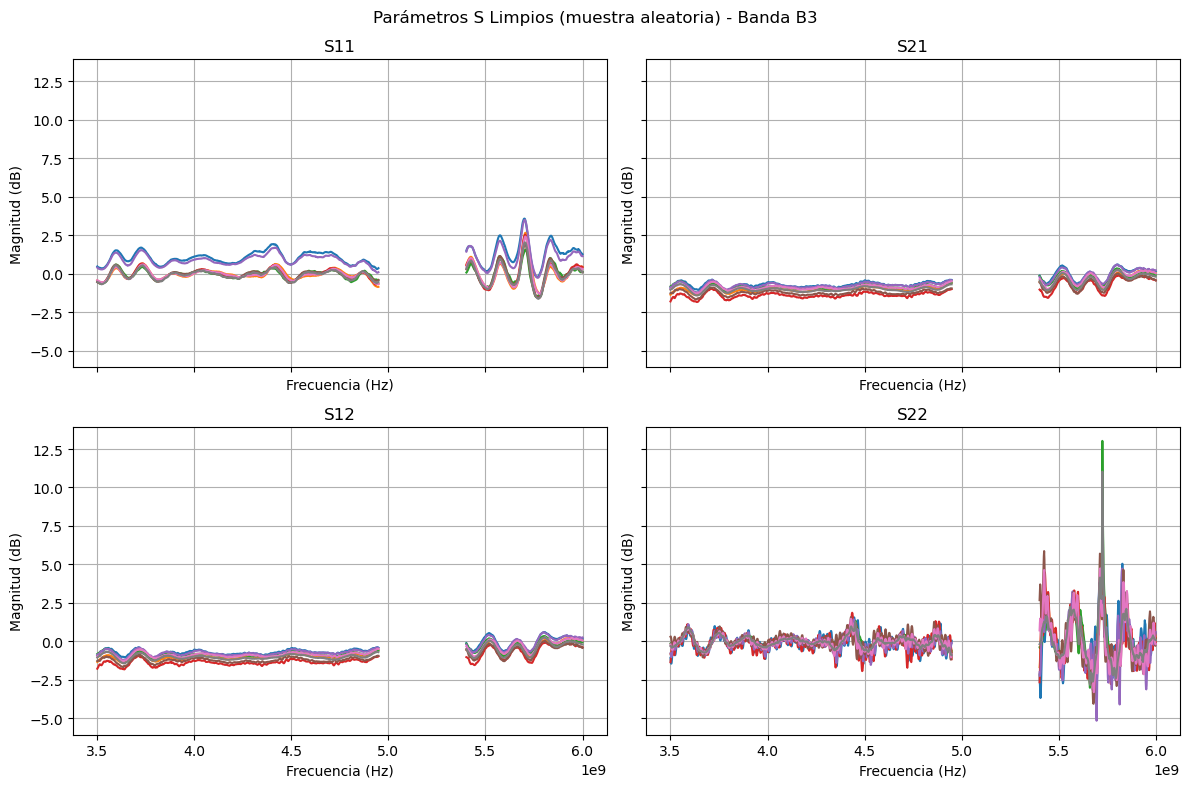

In [18]:
# Graficar solo algunas muestras limpias (aleatorias) usando funciones existentes
rng = np.random.default_rng(42)

n_por_banda = 8 

grouped_clean = group_networks_by_band(networks_clean)

sampled_grouped_clean = {}
for band in ('B1', 'B2', 'B3'):
    keys = list(grouped_clean[band].keys())
    if not keys:
        sampled_grouped_clean[band] = {}
        continue

    n = min(n_por_banda, len(keys))
    selected = list(rng.choice(keys, size=n, replace=False))
    sampled_grouped_clean[band] = {k: grouped_clean[band][k] for k in selected}
    print(f'{band}: mostrando {n} de {len(keys)} muestras limpias')

fig_b1_clean = plot_s_parameters_sameplot(
    sampled_grouped_clean['B1'],
    title='Parámetros S Limpios (muestra aleatoria) - Banda B1'
)
fig_b2_clean = plot_s_parameters_sameplot(
    sampled_grouped_clean['B2'],
    title='Parámetros S Limpios (muestra aleatoria) - Banda B2'
)
fig_b3_clean = plot_s_parameters_sameplot(
    sampled_grouped_clean['B3'],
    title='Parámetros S Limpios (muestra aleatoria) - Banda B3'
)

Derivado de la inspección visual durante la exploración de datos:

- Los cambios entre muestras son débiles y se concentran principalmente en la banda **B1**. En particular, en el parámetro S11 se observan variaciones pequeñas pero consistentes en el rango aproximado de 0.9–1.6 GHz. En S22, se identifica un notch alrededor de 1.4–1.5 GHz con ligeros desplazamientos entre curvas.
- En la banda **B2** se detecta una característica localizada (notch) en S11, cuya posición y profundidad varían entre mediciones, por lo que se considera un posible atributo relevante para el análisis.
- En la banda **B3**, las mediciones parecen estar dominadas por artefactos espurios. Debido a esto, se decide descartarlas para evitar la introducción de ruido en los modelos.

### Exploración estadística, variabilidad intra-muestra y separabilidad
Con base en lo anterior, se plantea una exploración estadística orientada a cuantificar la calidad de los datos. Tengo especial interés en evaluar la variabilidad intra-muestra, considerando las distintas orientaciones para cada parámetro.

Durante este proceso, se toman precauciones propias del análisis de datos de RF y microondas, como el desenvolvimiento de fase, con el fin de asegurar una interpretación consistente de los resultados.

In [19]:
# Variabilidad intra-muestra (orientaciones) para S11, S21, S12 y S22

def _safe_nanmean(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.nanmean(arr))

def _unwrap_phase_deg_with_nans(s_complex):
    """Desenvuelve fase en grados por segmentos validos, preservando NaN."""
    phase_deg = np.angle(s_complex, deg=True)
    out = np.full_like(phase_deg, np.nan, dtype=float)
    valid = np.isfinite(phase_deg)

    if not np.any(valid):
        return out

    idx = np.where(valid)[0]
    splits = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, splits)

    for seg in segments:
        seg_rad = np.deg2rad(phase_deg[seg].astype(float))
        out[seg] = np.rad2deg(np.unwrap(seg_rad))

    return out

def _sparam_to_indices(s_param):
    mapping = {
        'S11': (0, 0),
        'S21': (1, 0),
        'S12': (0, 1),
        'S22': (1, 1),
    }
    return mapping[s_param]

def _orientation_means_for_sparam(network, s_param):
    r, c = _sparam_to_indices(s_param)
    s_complex = network.s[:, r, c]

    mag_db = 20 * np.log10(np.maximum(np.abs(s_complex), 1e-12))
    phase_unwrapped_deg = _unwrap_phase_deg_with_nans(s_complex)

    return _safe_nanmean(mag_db), _safe_nanmean(phase_unwrapped_deg)

def _iter_valid_sample_records(networks, bands_to_use=None, include_air=False):
    # Iterador reutilizable: filtra y entrega solo registros validos de muestra.
    for key, ntwk in networks.items():
        parsed = parse_key(key)

        if parsed['is_air'] and not include_air:
            continue

        if bands_to_use is not None and parsed['band'] not in bands_to_use:
            continue

        if (
            parsed['sample_code'] is None
            or parsed['day_code'] is None
            or parsed['band'] is None
            or parsed['orientation'] is None
        ):
            continue

        yield parsed, ntwk

def build_groups_by_keys(networks, key_fields=('sample_code', 'day_code', 'band'), bands_to_use=None):
    # Generaliza el agrupado para distintos analisis del notebook.
    groups = {}

    for parsed, ntwk in _iter_valid_sample_records(networks, bands_to_use=bands_to_use):
        group_key = tuple(parsed[field] for field in key_fields)

        if 'band' in key_fields:
            if group_key not in groups:
                groups[group_key] = {}
            groups[group_key][parsed['orientation']] = ntwk
        else:
            band = parsed['band']
            orientation = parsed['orientation']
            if group_key not in groups:
                groups[group_key] = {}
            if band not in groups[group_key]:
                groups[group_key][band] = {}
            groups[group_key][band][orientation] = ntwk

    return groups

def build_intra_variability_df_wide(networks, s_params=('S11', 'S21', 'S12', 'S22')):
    required_orientations = ('O000', 'O120', 'O240')

    groups = build_groups_by_keys(
        networks,
        key_fields=('sample_code', 'day_code', 'band'),
    )

    rows = []
    for (sample_code, day_code, band), oriented_networks in sorted(groups.items()):
        if not all(o in oriented_networks for o in required_orientations):
            continue

        row = {
            'aguacate': sample_code,
            'dia': day_code,
            'banda': band,
        }

        has_any_metric = False
        for s_param in s_params:
            mag_means = []
            phase_means = []
            valid_group = True

            for orientation in required_orientations:
                mag_mean, phase_mean = _orientation_means_for_sparam(oriented_networks[orientation], s_param)

                if np.isnan(mag_mean) or np.isnan(phase_mean):
                    valid_group = False
                    break

                mag_means.append(mag_mean)
                phase_means.append(phase_mean)

            mag_col = f'std_mag_{s_param}'
            phase_col = f'std_phase_{s_param}'

            if valid_group:
                row[mag_col] = float(np.std(mag_means, ddof=1))
                row[phase_col] = float(np.std(phase_means, ddof=1))
                has_any_metric = True
            else:
                row[mag_col] = np.nan
                row[phase_col] = np.nan

        if has_any_metric:
            rows.append(row)

    df_wide = pd.DataFrame(rows)
    if df_wide.empty:
        return df_wide

    mag_cols = [f'std_mag_{sp}' for sp in s_params if f'std_mag_{sp}' in df_wide.columns]
    phase_cols = [f'std_phase_{sp}' for sp in s_params if f'std_phase_{sp}' in df_wide.columns]

    def _max_param_and_value(row, cols, prefix):
        # Force numeric dtype to avoid object/ufunc issues with np.isfinite.
        vals = pd.to_numeric(row[cols], errors='coerce')
        vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
        if vals.empty:
            return np.nan, np.nan

        max_col = vals.idxmax()
        max_val = float(vals.loc[max_col])
        max_param = max_col.replace(prefix, '')
        return max_param, max_val

    best_mag = df_wide.apply(lambda r: _max_param_and_value(r, mag_cols, 'std_mag_'), axis=1)
    best_phase = df_wide.apply(lambda r: _max_param_and_value(r, phase_cols, 'std_phase_'), axis=1)

    df_wide['param_mayor_var_mag'] = [x[0] for x in best_mag]
    df_wide['max_std_mag'] = [x[1] for x in best_mag]
    df_wide['param_mayor_var_phase'] = [x[0] for x in best_phase]
    df_wide['max_std_phase'] = [x[1] for x in best_phase]

    return df_wide

# Tabla de variabilidad intra-muestra (orientaciones) para S11, S21, S12 y S22
intra_variability_df = build_intra_variability_df_wide(networks_clean)

print('Filas en formato ancho:', len(intra_variability_df))
display(intra_variability_df.head())

Filas en formato ancho: 984


,aguacate,dia,banda,std_mag_S11,std_phase_S11,std_mag_S21,std_phase_S21,std_mag_S12,std_phase_S12,std_mag_S22,std_phase_S22,param_mayor_var_mag,max_std_mag,param_mayor_var_phase,max_std_phase
0,A01,D02,B1,0.008752,0.022706,0.003874,0.027791,0.003560,0.029389,0.002604,0.007705,S11,0.008752,S12,0.029389
1,A01,D02,B2,0.007417,0.004439,0.017747,0.021841,0.017379,0.020255,0.001946,0.031577,S21,0.017747,S22,0.031577
2,A01,D02,B3,0.008978,0.034095,0.042007,0.090520,0.040358,0.099364,0.000804,0.073258,S21,0.042007,S12,0.099364
3,A01,D03,B1,0.003957,0.005804,0.002571,0.041369,0.002528,0.041546,0.001842,0.003456,S11,0.003957,S12,0.041546
4,A01,D03,B2,0.000737,0.020441,0.012502,0.025555,0.012454,0.025150,0.002163,0.021994,S21,0.012502,S21,0.025555


La variabilidad intra-muestra, evaluada a partir de las distintas orientaciones de un mismo aguacate, es en general baja, lo que sugiere que la orientación del fruto tiene un efecto limitado en la respuesta medida. En B1, las desviaciones estándar en magnitud son pequeñas en todos los parámetros, con S11 como el más sensible, mientras que en fase se observan variaciones moderadas pero acotadas. En B2, la variabilidad en magnitud aumenta ligeramente en los parámetros de transmisión (S21 y S12), en línea con la presencia de características localizadas; sin embargo, esta variabilidad se mantiene en niveles bajos. Por el contrario, en B3 se observa un incremento notable en la variabilidad tanto en magnitud como en fase, particularmente en S21 y S12, lo que refuerza la presencia de artefactos en esta banda.

En conjunto, estos resultados indican que la respuesta del sistema es prácticamente invariante ante cambios en la orientación de la muestra. Desde el punto de vista físico, este comportamiento resulta atípico en mediciones de microondas, donde se esperaría que variaciones geométricas produjeran cambios apreciables en la respuesta electromagnética. La baja sensibilidad observada sugiere que el sistema de medición presenta una limitada respuesta a perturbaciones en la colocación de la muestra.

Dado lo anterior, para las bandas B1 y B2, la variabilidad intra-muestra es suficientemente baja como para justificar el promediado de las distintas orientaciones sin pérdida significativa de información. En contraste, la banda B3 presenta una dispersión significativamente mayor, por lo que se descarta de los análisis posteriores.

A continuación, se realizará un análisis de separabilidad interclases para las bandas B1 y B2, utilizando el promedio de las mediciones correspondientes a las distintas orientaciones de cada muestra.

In [20]:
BANDS_TO_USE = ('B1', 'B2')
S_PARAMS_TO_EVAL = ('S11', 'S22', 'S12', 'S21')
S_PARAM_TO_IDX = {
    'S11': (0, 0),
    'S21': (1, 0),
    'S12': (0, 1),
    'S22': (1, 1),
}

def _mean_sparam_over_orientations(networks_list, s_param):
    # Convierte varias orientaciones en una sola medición representativa por muestra/día.
    r, c = S_PARAM_TO_IDX[s_param]
    s_stack = np.stack([ntwk.s[:, r, c] for ntwk in networks_list], axis=0)
    s_mean = np.nanmean(s_stack, axis=0)
    f_hz = np.asarray(networks_list[0].f, dtype=float)
    return f_hz, s_mean

def build_separability_df_for_sparam(groups, label_dict, target_s_param, bands_to_use=('B1', 'B2')):
    # Generación de un dataset compacto para comparar separabilidad entre clases de madurez.
    rows = []

    for (sample_code, day_code), bands_dict in sorted(groups.items()):
        # Exigir que existan B1 y B2 con al menos una orientación.
        if any(len(bands_dict[b]) == 0 for b in bands_to_use):
            continue

        band_freqs = []
        band_smeans = []

        for band in bands_to_use:
            oriented_networks = [bands_dict[band][o] for o in sorted(bands_dict[band].keys())]
            f_hz, s_mean = _mean_sparam_over_orientations(oriented_networks, target_s_param)
            band_freqs.append(f_hz)
            band_smeans.append(s_mean)

        f_all = np.concatenate(band_freqs)
        s_all = np.concatenate(band_smeans)

        order = np.argsort(f_all)
        f_all = f_all[order]
        s_all = s_all[order]

        mag_db = 20 * np.log10(np.maximum(np.abs(s_all), 1e-12))
        finite_mag = np.isfinite(mag_db)
        if not np.any(finite_mag):
            continue

        idx_min_local = np.argmin(mag_db[finite_mag])
        idx_min_global = np.where(finite_mag)[0][idx_min_local]

        f_min = float(f_all[idx_min_global])
        min_val = float(mag_db[idx_min_global])

        phase_unwrapped = _unwrap_phase_deg_with_nans(s_all)
        mean_phase = float(np.nanmean(phase_unwrapped)) if np.any(np.isfinite(phase_unwrapped)) else np.nan

        label = label_dict.get((sample_code, day_code), np.nan)
        if pd.isna(label):
            continue

        rows.append({
            's_param': target_s_param,
            'sample_code': sample_code,
            'day_code': day_code,
            'label': label,
            'f_min': f_min,
            'min_val': min_val,
            'mean_phase': mean_phase,
        })

    return pd.DataFrame(rows)

def plot_separability_boxplots(separability_df, s_param):
    # Cajas de bigotes para comparar f_min, min_val y mean_phase entre clases.
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    sns.boxplot(data=separability_df, x='label', y='f_min', ax=axes[0])
    axes[0].set_title(f'{s_param}: f_min vs label')
    axes[0].set_xlabel('label')
    axes[0].set_ylabel('f_min (Hz)')

    sns.boxplot(data=separability_df, x='label', y='min_val', ax=axes[1])
    axes[1].set_title(f'{s_param}: min_val vs label')
    axes[1].set_xlabel('label')
    axes[1].set_ylabel('min_val (dB)')

    sns.boxplot(data=separability_df, x='label', y='mean_phase', ax=axes[2])
    axes[2].set_title(f'{s_param}: mean_phase vs label')
    axes[2].set_xlabel('label')
    axes[2].set_ylabel('mean_phase (deg)')

    for ax in axes:
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
    return fig

def run_separability_analysis_all_sparams(
    networks_norm,
    label_dict,
    bands_to_use=('B1', 'B2'),
    s_params=('S11', 'S21', 'S12', 'S22'),
    make_plots=True,
):
    groups = build_groups_by_keys(
        networks_norm,
        key_fields=('sample_code', 'day_code'),
        bands_to_use=bands_to_use,
    )

    results = {}
    summary_rows = []

    for s_param in s_params:
        separability_df = build_separability_df_for_sparam(
            groups,
            label_dict,
            target_s_param=s_param,
            bands_to_use=bands_to_use,
        )

        if separability_df.empty:
            class_stats = pd.DataFrame()
            n_classes = 0
        else:
            class_stats = separability_df.groupby('label')[['f_min', 'min_val', 'mean_phase']].agg(['mean', 'std'])
            n_classes = int(separability_df['label'].nunique())

        print(f'[{s_param}] Filas para separabilidad: {len(separability_df)}')
        display(separability_df.head())
        display(class_stats)

        if make_plots and not separability_df.empty:
            _ = plot_separability_boxplots(separability_df, s_param)

        results[s_param] = {
            'separability_df': separability_df,
            'class_stats': class_stats,
        }

        summary_rows.append({
            's_param': s_param,
            'n_filas': len(separability_df),
            'n_clases': n_classes,
        })

    summary_df = pd.DataFrame(summary_rows)
    print('Resumen por parametro S:')
    display(summary_df)

    return results, summary_df

[S11] Filas para separabilidad: 328


,s_param,sample_code,day_code,label,f_min,min_val,mean_phase
0,S11,A01,D02,verde,1.555938e+09,-2.486880,0.083606
1,S11,A01,D03,maduro,1.559375e+09,-2.187258,0.172888
2,S11,A01,D04,maduro,1.560062e+09,-2.241422,-0.049843
3,S11,A01,D05,maduro,1.558000e+09,-2.409003,-0.106918
4,S11,A01,D06,maduro,1.559375e+09,-2.323053,-0.092739


f_min                 min_val           mean_phase          
                mean           std      mean       std       mean       std
label                                                                      
maduro  1.557292e+09  4.024709e+06 -2.290273  0.271257   0.173925  0.625580
pasado  1.556859e+09  2.732974e+07 -2.277951  0.218996  -0.046988  0.071974
verde   1.548783e+09  3.477683e+07 -2.304516  0.266636  -0.142138  0.110539

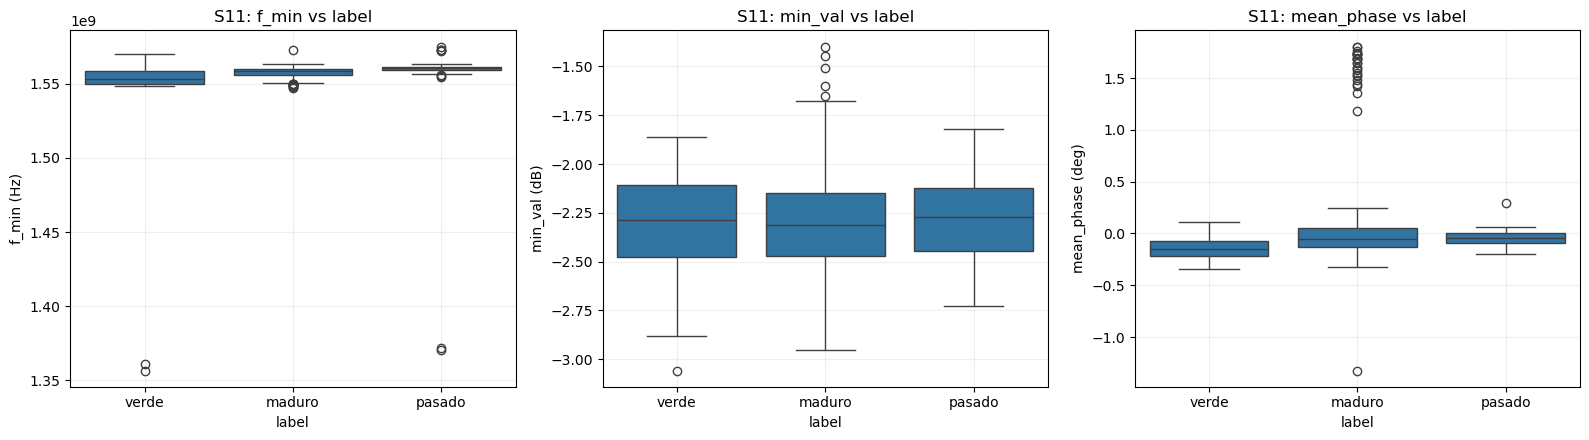

[S22] Filas para separabilidad: 328


,s_param,sample_code,day_code,label,f_min,min_val,mean_phase
0,S22,A01,D02,verde,1.443188e+09,-4.014487,-0.067318
1,S22,A01,D03,maduro,1.455562e+09,-2.291212,0.144325
2,S22,A01,D04,maduro,2.910312e+09,-9.067059,-0.044913
3,S22,A01,D05,maduro,1.087062e+09,-3.476712,-0.030363
4,S22,A01,D06,maduro,1.093250e+09,-4.623829,-0.058067


f_min                 min_val           mean_phase          
                mean           std      mean       std       mean       std
label                                                                      
maduro  1.530133e+09  6.576900e+08 -4.814879  2.289956  -0.101951  0.107621
pasado  1.101819e+09  1.247729e+07 -4.889873  0.743524  -0.223579  0.137423
verde   2.218039e+09  7.747188e+08 -3.806147  1.198537  -0.174150  0.122882

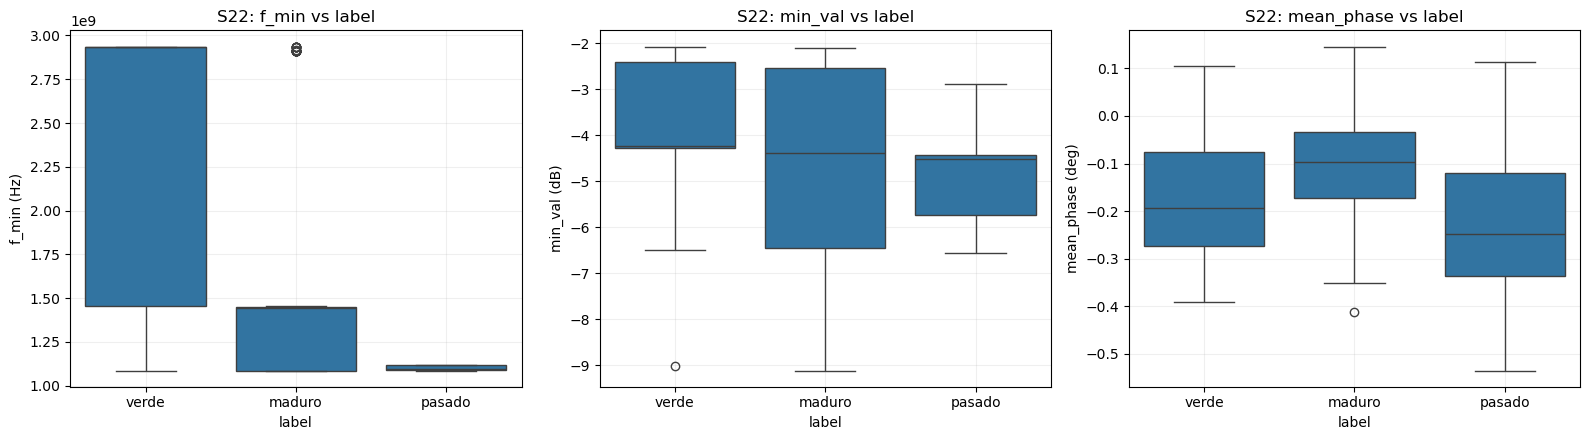

[S12] Filas para separabilidad: 328


,s_param,sample_code,day_code,label,f_min,min_val,mean_phase
0,S12,A01,D02,verde,2.719062e+09,-1.220204,-11.565646
1,S12,A01,D03,maduro,3.450062e+09,-1.194471,-12.097285
2,S12,A01,D04,maduro,2.910312e+09,-1.818337,-12.104676
3,S12,A01,D05,maduro,3.453250e+09,-1.150282,-12.101549
4,S12,A01,D06,maduro,3.454312e+09,-1.140945,-11.998946


f_min                 min_val           mean_phase          
                mean           std      mean       std       mean       std
label                                                                      
maduro  3.366519e+09  1.848493e+08 -1.447154  0.320926 -13.657267  1.179741
pasado  3.458267e+09  2.523540e+06 -1.488539  0.190724 -14.010850  1.109388
verde   3.416262e+09  1.467026e+08 -1.480662  0.199847 -13.901611  1.229249

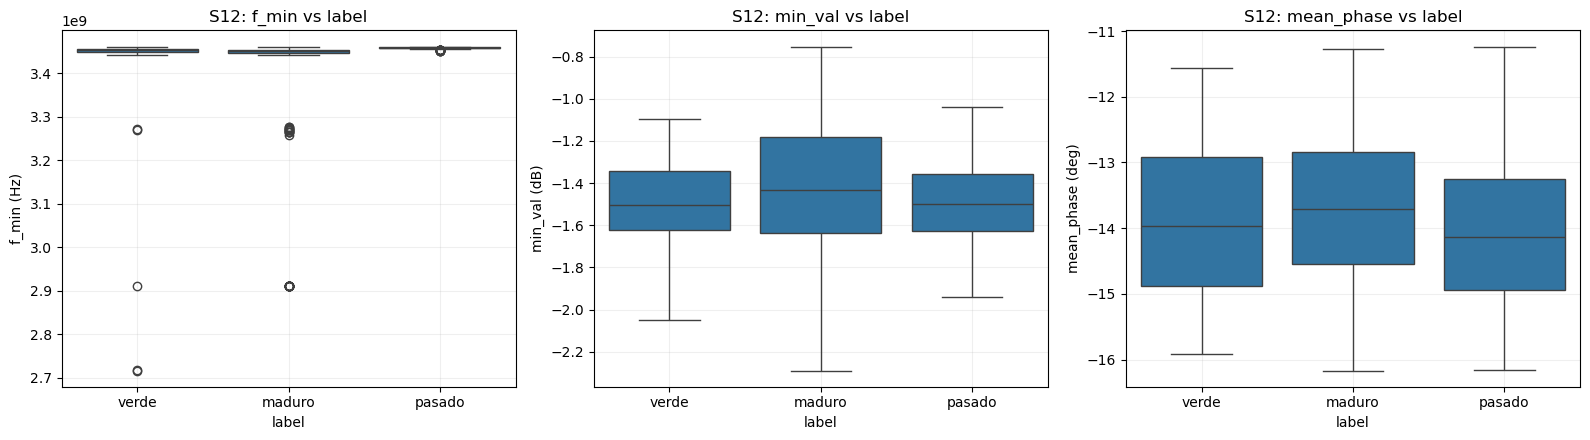

[S21] Filas para separabilidad: 328


,s_param,sample_code,day_code,label,f_min,min_val,mean_phase
0,S21,A01,D02,verde,2.698875e+09,-1.233308,-11.693977
1,S21,A01,D03,maduro,3.451125e+09,-1.193683,-12.085458
2,S21,A01,D04,maduro,2.910312e+09,-1.811932,-12.082312
3,S21,A01,D05,maduro,3.451125e+09,-1.152965,-12.124912
4,S21,A01,D06,maduro,3.456438e+09,-1.139376,-11.999326


f_min                 min_val           mean_phase          
                mean           std      mean       std       mean       std
label                                                                      
maduro  3.366602e+09  1.848340e+08 -1.447673  0.320167 -13.682499  1.190163
pasado  3.457675e+09  3.152868e+06 -1.493549  0.192112 -14.086603  1.117985
verde   3.416262e+09  1.484169e+08 -1.482276  0.199400 -13.912766  1.217212

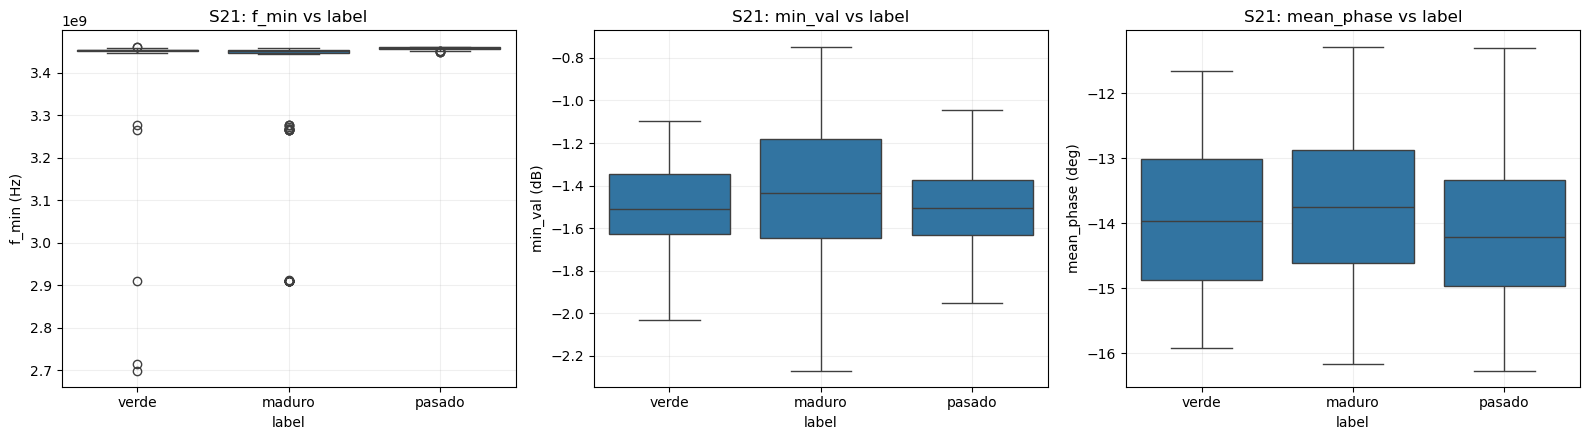

Resumen por parametro S:


,s_param,n_filas,n_clases
0,S11,328,3
1,S22,328,3
2,S12,328,3
3,S21,328,3


In [21]:
separability_results, separability_summary = run_separability_analysis_all_sparams(
    networks_norm,
    label_dict,
    bands_to_use=BANDS_TO_USE,
    s_params=S_PARAMS_TO_EVAL,
    make_plots=True,
)

Se observa que la separabilidad entre clases es limitada y depende del parámetro y del tipo de medición (reflexión vs transmisión).

Para S11 (reflexión en el puerto de entrada ), la variable más discriminante es la fase media (mean_phase), donde se mantiene una tendencia general (verde < pasado < maduro). Sin embargo, la clase maduro presenta una dispersión considerable y múltiples outliers, lo que genera un traslape importante con las otras clases. Las variables f_min y min_val muestran diferencias pequeñas entre clases y un alto grado de solapamiento, por lo que su capacidad discriminante es limitada.

En S22, no se observa una separabilidad consistente. La frecuencia f_min presenta una dispersión muy alta, especialmente en la clase verde, lo que indica inestabilidad del feature. La variable min_val muestra cierto desplazamiento entre clases, pero con una varianza elevada que reduce su utilidad. La fase (mean_phase) presenta ligeras diferencias en tendencia, aunque con un solapamiento considerable. En conjunto, S22 no ofrece una discriminación robusta.

Para S12 y S21 (parámetros de transmisión ), los resultados son consistentes entre sí. La variable f_min muestra muy poca variabilidad intra-clase, pero también una separación mínima entre clases. En min_val y mean_phase se observan ligeras diferencias en tendencia (valores más negativos para verde), aunque el grado de solapamiento sigue siendo alto, lo que limita su capacidad discriminante.

En conjunto, los resultados indican que:

La separabilidad interclases es limitada con estos features agregados.
S11 (fase) es el único parámetro que muestra una tendencia consistente, aunque con solapamiento significativo.
S22 presenta alta variabilidad e inestabilidad, especialmente en f_min.
S12/S21 son más estables, pero con baja capacidad de separación entre clases.

Esto sugiere que, para mejorar la separabilidad, será necesario utilizar representaciones más ricas (por ejemplo, información espectral completa o features derivados más complejos), en lugar de depender únicamente de métricas agregadas como mínimos o promedios.

## Extracción de características

A partir del análisis exploratorio realizado, se observó que las variaciones en las mediciones son de baja magnitud y que la separabilidad entre clases no es evidente en las características inicialmente consideradas. No obstante, es posible que la información relevante no sea directamente observable en representaciones simples, sino que se encuentre distribuida en patrones más sutiles dentro de la señal.

Por esta razón, en esta sección se propone una extracción más amplia de características a partir de los parámetros de dispersión, con el objetivo de capturar de manera más completa la información contenida en las mediciones. Estas características incluirán descriptores tanto en magnitud como en fase para los cuatro parámetros S (S11, S21, S12 y S22), así como métricas que permitan representar comportamientos locales y globales de la señal.

El propósito de esta etapa es construir un espacio de características más rico que permita evaluar si, mediante técnicas de aprendizaje automático, es posible identificar patrones no evidentes en el análisis exploratorio y, en consecuencia, mejorar la capacidad de discriminación entre los estados de maduración.

In [22]:
# STD
def _safe_std(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        return np.nan
    return float(np.std(arr, ddof=1))

# Estadísticas básicas
def _basic_stats(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return {
            'mean': np.nan,
            'std': np.nan,
            'range': np.nan
        }

    return {
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr, ddof=1)) if arr.size > 1 else 0.0,
        'range': float(np.max(arr) - np.min(arr))
    }

# Notch features (Considerando NaN)
def _notch_features(f, mag_db):
    f = np.asarray(f)
    mag_db = np.asarray(mag_db)

    # Filtrar valores válidos
    valid = np.isfinite(mag_db)

    if np.sum(valid) < 5:
        return {
            'f_min': np.nan,
            'mag_min': np.nan,
            'depth': np.nan,
            'bw_3db': np.nan
        }

    f_valid = f[valid]
    mag_valid = mag_db[valid]

    idx = np.argmin(mag_valid)
    f_min = f_valid[idx]
    mag_min = mag_valid[idx]

    depth = np.median(mag_valid) - mag_min

    thr = mag_min + 3

    left = idx
    while left > 0 and mag_valid[left] <= thr:
        left -= 1

    right = idx
    while right < len(mag_valid) - 1 and mag_valid[right] <= thr:
        right += 1

    bw = f_valid[right] - f_valid[left] if right > left else np.nan

    return {
        'f_min': float(f_min),
        'mag_min': float(mag_min),
        'depth': float(depth),
        'bw_3db': float(bw)
    }

# Extracción de características 
def extract_simple_features(f, s_complex):
    mag = np.abs(s_complex)
    mag_db = 20 * np.log10(np.maximum(mag, 1e-12))
    phase = np.angle(s_complex)

    feat = {}

    # Notch
    feat.update(_notch_features(f, mag_db))

    # Magnitud global
    mag_stats = _basic_stats(mag_db)
    for k, v in mag_stats.items():
        feat[f'mag_{k}'] = v

    # Fase (variabilidad)
    feat['phase_std'] = _safe_std(phase)

    valid_phase = np.isfinite(phase)
    if np.sum(valid_phase) < 2:
        feat['phase_range'] = np.nan
    else:
        feat['phase_range'] = float(
            np.max(phase[valid_phase]) - np.min(phase[valid_phase])
        )

    return feat

Construye el dataset para cada muestra/día para B1 y B2:

In [23]:

def build_dataset(networks, label_dict):

    # Construcción de un dataset tabular con características extraídas para cada muestra/día/banda, usando el promedio entre orientaciones.
    groups = {}

    for key, ntwk in networks.items():
        parsed = parse_key(key)

        if parsed['band'] not in ['B1', 'B2']:
            continue

        if parsed['orientation'] not in ['O000', 'O120', 'O240']:
            continue

        gkey = (parsed['sample_code'], parsed['day_code'], parsed['band'])

        if gkey not in groups:
            groups[gkey] = []

        groups[gkey].append(ntwk)

    rows = []

    s_param_map = {
        'S11': (0, 0),
        'S21': (1, 0),
        'S12': (0, 1),
        'S22': (1, 1),
    }

    for (sample, day, band), ntwks in groups.items():

        if len(ntwks) < 3:
            continue

        label = label_dict.get((sample, day), None)
        if label is None:
            continue

        row = {
            'sample': sample,
            'day': day,
            'band': band,
            'label': label
        }

        for s_name, (r, c) in s_param_map.items():

            # Promedio entre orientaciones
            s_stack = np.array([n.s[:, r, c] for n in ntwks])
            s_mean = np.mean(s_stack, axis=0)
            f = ntwks[0].f

            feats = extract_simple_features(f, s_mean)

            for k, v in feats.items():
                row[f'{band}_{s_name}_{k}'] = v

        rows.append(row)

    return pd.DataFrame(rows)

# Construir dataset base
rich_features_df = build_dataset(networks_clean, label_dict)
#print(f'Dataset base: {rich_features_df}')

# Pivot
df_wide = rich_features_df.pivot_table(
    index=['sample', 'day', 'label'],
    columns='band',
    aggfunc='mean'
).reset_index()

# Aplanar columnas conservando sample/day/label y separando features por banda
flat_cols = []
for col in df_wide.columns.to_flat_index():
    if isinstance(col, tuple):
        left, right = col
        flat_cols.append(left if right == '' else f'{left}_{right}')
    else:
        flat_cols.append(col)
df_wide.columns = flat_cols

#print(f'Dataset pivotado: {df_wide}')
print(f'Dataset pivotado: {df_wide.shape}')

# Construcción de matriz de entrada y matriz objetivo
meta_cols = ['sample', 'day', 'label']
feature_cols = [c for c in df_wide.columns if c not in meta_cols]

X = df_wide[feature_cols].apply(pd.to_numeric, errors='coerce')
X = X.loc[:, X.notna().any()]
y = df_wide['label']

print(f'X: {X.shape} | y: {y.shape}')

# Imputación
X_imp = X.fillna(X.median(numeric_only=True))

Dataset pivotado: (328, 75)
X: (328, 72) | y: (328,)


## Selección de características

Con el fin de reducir la dimensionalidad del problema y seleccionar las variables más relevantes para la tarea de clasificación, se implementó un proceso de selección de características sobre el conjunto de datos.

Para ello, se aplican tres etapas principales: 
- I Eliminación de características con baja varianza; 
- II Eliminación de variables altamente correlacionadas, con el fin de evitar redundancia en la información.
- III Evaluación de la relevancia de cada característica mediante información mutua, esta permite cuantificar la dependencia estadística entre cada feature y la variable objetivo.

In [24]:
def variance_threshold_selector(X, threshold=1e-6):
    vt = VarianceThreshold(threshold=threshold)
    X_vt = pd.DataFrame(
        vt.fit_transform(X),
        columns=X.columns[vt.get_support()]
    )
    return X_vt

def correlation_filter(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    X_corr = X.drop(columns=to_drop)
    return X_corr

def mutual_info_classif_selector(X, y, random_state=42):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    mi_scores = mutual_info_classif(X, y_enc, random_state=random_state)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

    print('Top 10 características (información mutua):')
    print(mi_series.head(10))

    return mi_series


In [25]:
print('\n=== FEATURE SELECTION GLOBAL (NO USAR PARA ENTRENAMIENTO PARA EVITAR LEAKAGE) ===')

# Construcción local para evitar inconsistencias por estado del notebook
meta_cols = ['sample', 'day', 'label']
df_global = df_wide.copy()

X_global = df_global.drop(columns=meta_cols).apply(pd.to_numeric, errors='coerce')
X_global = X_global.loc[:, X_global.notna().any()]
y_global = df_global['label']

X_global_imp = X_global.fillna(X_global.median(numeric_only=True))

X_vt = variance_threshold_selector(X_global_imp, threshold=1e-6)
X_corr = correlation_filter(X_vt, threshold=0.95)
mi_series = mutual_info_classif_selector(X_corr, y_global, random_state=42)

# Selección final
k_features = min(15, len(mi_series))
selected_features = mi_series.head(k_features).index.tolist()

selected_model_df = pd.concat(
    [df_global[meta_cols], X_corr[selected_features]],
    axis=1
)

print(f'Dataset final (GLOBAL): {selected_model_df.shape}')


=== FEATURE SELECTION GLOBAL (NO USAR PARA ENTRENAMIENTO PARA EVITAR LEAKAGE) ===
Top 10 características (información mutua):
B2_S12_f_min_B2        0.385788
B2_S22_f_min_B2        0.244585
B1_S11_f_min_B1        0.213956
B2_S22_mag_range_B2    0.209636
B2_S11_f_min_B2        0.189614
B1_S12_depth_B1        0.183377
B1_S12_phase_std_B1    0.180286
B2_S22_mag_mean_B2     0.178877
B1_S12_f_min_B1        0.162881
B2_S22_depth_B2        0.161245
dtype: float64
Dataset final (GLOBAL): (328, 18)


El análisis de relevancia mediante información mutua permitió identificar un subconjunto de características con mayor dependencia respecto a la variable objetivo. En particular, se observa que las features asociadas a la frecuencia del mínimo ($f_{min}$) en varios parámetros de dispersión presentan los valores más altos de información mutua, alcanzando valores del orden de 0.3, lo que sugiere una relación moderada con el estado de maduración.

Sin embargo, se observa una presencia dominante de características derivadas de S22 y S12 dentro de las variables mejor rankeadas. Sin embargo, derivado de la sección EDA se observó que las mediciones en S22 presentan un comportamiento irregular, por lo cuál considero que este resultado debe interpretarse con cautela, desde la exploración se identificó que este parámetro presentas artefactos que pueden estar asociados a la configuración experimental. Esto sugiere que parte de la relevancia atribuida a estas características podría estar influenciada por variaciones no relacionadas directamente con las propiedades internas del fruto, sino con efectos del sistema de medición.

En contraste, las características asociadas a S11, particularmente aquellas relacionadas con la posición del mínimo y métricas globales de magnitud, también muestran una contribución relevante.

En conjunto, aunque el proceso de selección de características permite identificar variables con cierta capacidad discriminativa, los resultados deben considerarse con reserva, ya que parte de la información capturada podría estar asociada a artefactos del sistema más que a cambios intrínsecos en el estado de maduración.

## Entrenamiento de modelos

Para el entrenamiento y evaluación de los modelos se empleó un esquema de validación cruzada tipo **Leave-One-Sample-Out (LOSO)**. En este enfoque, todas las mediciones asociadas a un mismo aguacate se excluyen del entrenamiento y se utilizan exclusivamente para prueba en cada iteración.

La elección de LOSO se debe a la estructura del conjunto de datos, donde cada muestra cuenta con múltiples mediciones (distintas orientaciones y condiciones). Bajo esquemas de validación convencionales, es posible que mediciones del mismo aguacate se distribuyan entre los conjuntos de entrenamiento y prueba, introduciendo fuga de información (data leakage) y produciendo estimaciones artificialmente optimistas del desempeño del modelo.

El uso de LOSO garantiza que el modelo sea evaluado sobre muestras completamente no vistas, reflejando de manera más realista su capacidad de generalización a nuevos frutos.

### Linear Regression

El entrenamiento inicial se realizó utilizando un modelo de regresión lineal con fines de evaluación, con el objetivo de establecer una línea base que permitiera valorar la capacidad predictiva de las variables seleccionadas.

Cabe mencionar que la muestra A21 no presentó un proceso de maduración convencional -no maduró-, por lo que fue excluida del conjunto de entrenamiento para evitar introducir sesgos en el modelo.

In [41]:
df_clean = df_wide[df_wide['sample'] != 'A21'].copy()
meta_cols = ['sample', 'day', 'label']

X = df_clean.drop(columns=meta_cols)
y = df_clean['label']
groups = df_clean['sample']

def _fit_fold_transformers(
    X_train,
    y_train,
    use_mi=True,
    variance_threshold=1e-6,
    corr_threshold=0.95,
    k_features=15,
):
    """Ajusta transformaciones SOLO con train y regresa columnas seleccionadas."""
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )

    X_vt = variance_threshold_selector(X_train_imp, threshold=variance_threshold)
    X_corr = correlation_filter(X_vt, threshold=corr_threshold)

    selected_features = list(X_corr.columns)
    if use_mi and len(selected_features) > 0:
        mi_series = mutual_info_classif_selector(X_corr, y_train)
        k = min(k_features, len(mi_series))
        selected_features = mi_series.head(k).index.tolist()

    scaler = StandardScaler()
    scaler.fit(X_corr[selected_features])

    return {
        'imputer': imputer,
        'selected_features': selected_features,
        'scaler': scaler,
    }

def _transform_with_fitted(X_data, fitted):
    """Aplica al split actual lo aprendido en train del fold."""
    X_imp = pd.DataFrame(
        fitted['imputer'].transform(X_data),
        columns=X_data.columns,
        index=X_data.index,
    )
    X_sel = X_imp[fitted['selected_features']]
    X_scaled = fitted['scaler'].transform(X_sel)
    return X_scaled

def _count_selected_by_sparam(selected_features):
    counts = {'S11': 0, 'S21': 0, 'S12': 0, 'S22': 0, 'otras': 0}
    for feat in selected_features:
        matched = False
        for s_param in ('S11', 'S21', 'S12', 'S22'):
            if f'_{s_param}_' in feat:
                counts[s_param] += 1
                matched = True
                break
        if not matched:
            counts['otras'] += 1
    counts['total'] = len(selected_features)
    return counts

def run_loso_experiment(
    X_data,
    y_data,
    groups_data,
    use_mi=True,
    variance_threshold=1e-6,
    corr_threshold=0.95,
    k_features=15,
    title='LOSO',
):
    logo = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    accuracies = []
    fold_feature_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_data, y_data, groups_data), start=1):
        X_train = X_data.iloc[train_idx].copy()
        X_test = X_data.iloc[test_idx].copy()
        y_train = y_data.iloc[train_idx]
        y_test = y_data.iloc[test_idx]

        fitted = _fit_fold_transformers(
            X_train,
            y_train,
            use_mi=use_mi,
            variance_threshold=variance_threshold,
            corr_threshold=corr_threshold,
            k_features=k_features,
        )

        selected_counts = _count_selected_by_sparam(fitted['selected_features'])
        fold_feature_rows.append({'fold': fold_idx, **selected_counts})

        X_train_final = _transform_with_fitted(X_train, fitted)
        X_test_final = _transform_with_fitted(X_test, fitted)

        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train_final, y_train)
        y_pred = clf.predict(X_test_final)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        accuracies.append(accuracy_score(y_test, y_pred))

    fold_feature_summary_df = pd.DataFrame(fold_feature_rows)

    print(f'Accuracy promedio ({title}): {np.mean(accuracies):.3f}')
    print(f'Desviación estándar de Accuracy: {np.std(accuracies):.3f}')
    print('\nReporte de clasificación:')
    print(classification_report(y_true_all, y_pred_all, zero_division=0))

    print('\nResumen por fold de features seleccionadas (por parámetro S):')
    display(fold_feature_summary_df)

    print('\nPromedio de features seleccionadas por parámetro S:')
    print(
        fold_feature_summary_df[['S11', 'S21', 'S12', 'S22', 'otras', 'total']]
        .mean()
        .round(2)
    )

    return {
        'accuracies': accuracies,
        'y_true_all': y_true_all,
        'y_pred_all': y_pred_all,
        'fold_feature_summary': fold_feature_summary_df,
    }

def run_train_test_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    use_mi=False,
    variance_threshold=1e-6,
    corr_threshold=0.95,
    k_features=15,
    title='Entrenamiento/Prueba',
):
    fitted = _fit_fold_transformers(
        X_train,
        y_train,
        use_mi=use_mi,
        variance_threshold=variance_threshold,
        corr_threshold=corr_threshold,
        k_features=k_features,
    )

    X_train_final = _transform_with_fitted(X_train, fitted)
    X_test_final = _transform_with_fitted(X_test, fitted)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_final, y_train)
    y_pred = clf.predict(X_test_final)

    print(f'\nResultados ({title})')
    print('Reporte de clasificación:')
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        'y_pred': y_pred,
        'selected_features': fitted['selected_features'],
    }

loso_main_results = run_loso_experiment(
    X_data=X,
    y_data=y,
    groups_data=groups,
    use_mi=True,
    k_features=15,
    title='LOSO (sin A21)',
)

Top 10 características (información mutua):
B2_S12_f_min_B2        0.412880
B2_S21_f_min_B2        0.367843
B2_S22_f_min_B2        0.258475
B2_S22_mag_range_B2    0.257139
B1_S11_f_min_B1        0.234217
B1_S12_f_min_B1        0.231299
B1_S12_depth_B1        0.224974
B2_S22_mag_mean_B2     0.205364
B1_S22_f_min_B1        0.203238
B2_S22_depth_B2        0.184445
dtype: float64
Top 10 características (información mutua):
B2_S12_f_min_B2        0.393482
B2_S22_f_min_B2        0.269830
B2_S22_mag_range_B2    0.250261
B1_S12_f_min_B1        0.218895
B1_S12_depth_B1        0.217365
B2_S22_mag_mean_B2     0.186094
B2_S11_f_min_B2        0.183088
B1_S11_f_min_B1        0.179484
B1_S22_f_min_B1        0.168227
B2_S22_depth_B2        0.166164
dtype: float64
Top 10 características (información mutua):
B2_S12_f_min_B2        0.390505
B2_S22_f_min_B2        0.250900
B2_S22_mag_range_B2    0.246021
B1_S12_f_min_B1        0.218012
B1_S12_depth_B1        0.214602
B2_S22_mag_mean_B2     0.200723
B2_S11

,fold,S11,S21,S12,S22,otras,total
0,1,3,1,4,7,0,15
1,2,3,0,5,7,0,15
2,3,3,0,4,8,0,15
3,4,3,0,4,8,0,15
4,5,3,0,4,8,0,15
5,6,3,0,5,7,0,15
6,7,3,1,4,7,0,15
7,8,3,0,4,8,0,15
8,9,3,0,4,8,0,15
9,10,3,0,4,8,0,15



Promedio de features seleccionadas por parámetro S:
S11       3.00
S21       0.04
S12       4.35
S22       7.60
otras     0.00
total    15.00
dtype: float64


En términos de desempeño, el modelo alcanza una exactitud de 0.83 bajo el esquema LOSO. A nivel de clases, se obtienen valores de F1-score de 0.85 para maduro, 0.84 para pasado y 0.74 para verde, lo que indica un desempeño relativamente balanceado, aunque con menor capacidad de discriminación en la clase verde.

La degradación observada en la clase verde (F1-score ≈ 0.74) puede estar asociada tanto a condiciones experimentales como a la menor representatividad de esta clase en el conjunto de datos (support = 57). En particular, durante el día 02 —correspondiente principalmente a muestras en estado verde— se registró un pequeño ajuste en la cámara de la configuración del sistema alrededor del aguacate A11, lo cual introduce una variación sistemática en las mediciones no relacionada con el estado del fruto.

Dado que el modelo ha mostrado sensibilidad a variaciones en la respuesta del sistema, este tipo de perturbaciones puede afectar de manera desproporcionada a una clase específica. En consecuencia, la menor precisión en la clase verde podría estar reflejando variabilidad inducida por el sistema de medición, más que una falta de separabilidad intrínseca entre clases.

A partir del proceso de selección de características, se observó que las variables asociadas a la frecuencia del mínimo ($f_{min}$) dominan de manera consistente el ranking de relevancia en todos los folds de validación . En términos agregados, la selección de características se concentra principalmente en S22 y S12, seguida de S11, mientras que S21 tiene una contribución prácticamente nula .

Este resultado es consistente desde el punto de vista estadístico, pero introduce una discrepancia desde la interpretación física del problema. En una configuración de medición en espacio libre como esta, se esperaría que los parámetros de transmisión (S21 y S12) fueran los más sensibles a cambios en las propiedades internas del fruto. Sin embargo, el modelo asigna mayor relevancia a variables asociadas a reflexión y, en particular, a desplazamientos en frecuencia.

Sin embargo, el modelo asigna mayor relevancia a variables asociadas a reflexión y, en particular, a desplazamientos en frecuencia. En conjunto, estos resultados sugieren que el modelo podría estar capturando variaciones asociadas al sistema de medición más que propiedades intrínsecas del fruto.

En particular, dado que las mediciones están organizadas por día y que existen evidencias de cambios en las condiciones experimentales, es posible que el modelo esté utilizando indirectamente información relacionada con condiciones de adquisición (por ejemplo, variaciones ambientales o cambios en el acoplamiento entre antenas) para realizar la clasificación.

Desde el punto de vista electromagnético, la interacción entre antenas cercanas puede dar lugar a fenómenos de acoplamiento mutuo, donde la respuesta medida depende no solo del objeto bajo prueba, sino también de la interacción entre los elementos del sistema . A partir de la inspección directa de las señales y del conocimiento del sistema, se plantea que la respuesta observada podría estar dominada por estos efectos de acoplamiento, en lugar de por la interacción de la onda con el interior del aguacate.

Bajo esta interpretación, los desplazamientos en frecuencia $f_{min}$ reflejarían cambios en la geometría efectiva del sistema o en las condiciones de medición, lo que explicaría tanto su alta relevancia como el desempeño elevado del modelo.

Con el objetivo de evaluar esta hipótesis, se realizó un análisis de sensibilidad en el cual se excluyeron deliberadamente todas las características relacionadas con $f_{min}$. Este experimento no busca eliminar información relevante de manera definitiva, sino analizar la robustez del modelo y determinar si existen otras características con capacidad discriminativa independiente.

En este sentido, el interés no radica únicamente en el desempeño del modelo, sino en comprender qué tipo de información está siendo utilizada para la clasificación. En particular, se busca distinguir si el modelo está capturando propiedades físicas del fruto o si su desempeño depende de variaciones asociadas al sistema de medición.

In [27]:
# Identificar features que contienen f_min
fmin_cols = [c for c in X.columns if 'f_min' in c]

print(f'Eliminando {len(fmin_cols)} features f_min')

# Nuevo dataset sin f_min
X_no_fmin = X.drop(columns=fmin_cols)

Eliminando 8 features f_min


In [28]:
loso_no_fmin_results = run_loso_experiment(
    X_data=X_no_fmin,
    y_data=y,
    groups_data=groups,
    use_mi=False,
    title='SIN f_min',
)

Accuracy promedio (SIN f_min): 0.841
Desviación estándar de Accuracy: 0.133

Reporte de clasificación:
              precision    recall  f1-score   support

      maduro       0.84      0.89      0.86       167
      pasado       0.90      0.88      0.89        97
       verde       0.80      0.72      0.76        57

    accuracy                           0.85       321
   macro avg       0.85      0.83      0.84       321
weighted avg       0.85      0.85      0.85       321


Resumen por fold de features seleccionadas (por parámetro S):


,fold,S11,S21,S12,S22,otras,total
0,1,11,0,11,12,0,34
1,2,11,0,11,12,0,34
2,3,11,0,11,12,0,34
3,4,11,0,11,12,0,34
4,5,11,0,11,12,0,34
5,6,11,0,11,12,0,34
6,7,11,0,11,12,0,34
7,8,11,0,11,12,0,34
8,9,11,0,11,12,0,34
9,10,11,0,11,12,0,34



Promedio de features seleccionadas por parámetro S:
S11      10.98
S21       0.00
S12      11.00
S22      12.00
otras     0.00
total    33.98
dtype: float64


Tras eliminar las variables asociadas a $f_{min}$, el modelo mantiene un desempeño aceptable, lo que indica que la capacidad predictiva no depende exclusivamente de esta característica. Esto sugiere que existen otras variables dentro del conjunto de datos que contienen información suficientemente discriminativa para realizar la clasificación.

Sin embargo, el análisis de selección de variables muestra que el parámetro S21 no es seleccionado en ningún fold, mientras que las variables relevantes provienen principalmente de S11, S22 y S12. Este patrón se mantiene de manera consistente, incluso al ampliar el número de características consideradas.

Desde el punto de vista físico, este resultado es inconsistente con lo esperado, ya que S21 está directamente asociado a la transmisión de energía a través de la muestra y debería ser más sensible a las propiedades internas del fruto. En contraste, los parámetros de reflexión están más influenciados por condiciones de acoplamiento y geometría del sistema.

En conjunto, estos hallazgos sugieren que el modelo está capturando variaciones asociadas al sistema de medición —como cambios en el acoplamiento entre antenas o en las condiciones experimentales— más que propiedades intrínsecas del aguacate.

Para poner a prueba esta hipótesis, se realizará un nuevo experimento considerando únicamente el parámetro S11 (reflexión en la antena de transmisión), con el objetivo de evaluar si el modelo mantiene su capacidad predictiva utilizando exclusivamente información asociada al comportamiento del sistema.

In [29]:
# Mantener solo columnas de S11
s11_cols = [c for c in X.columns if 'S11' in c]

print(f'Usando {len(s11_cols)} features de S11')

X_s11 = X[s11_cols].copy()

Usando 18 features de S11


In [30]:
loso_s11_results = run_loso_experiment(
    X_data=X_s11,
    y_data=y,
    groups_data=groups,
    use_mi=False,
    title='solo S11',
)

Accuracy promedio (solo S11): 0.780
Desviación estándar de Accuracy: 0.154

Reporte de clasificación:
              precision    recall  f1-score   support

      maduro       0.80      0.86      0.83       167
      pasado       0.82      0.79      0.81        97
       verde       0.68      0.56      0.62        57

    accuracy                           0.79       321
   macro avg       0.77      0.74      0.75       321
weighted avg       0.78      0.79      0.78       321


Resumen por fold de features seleccionadas (por parámetro S):


,fold,S11,S21,S12,S22,otras,total
0,1,13,0,0,0,0,13
1,2,13,0,0,0,0,13
2,3,13,0,0,0,0,13
3,4,13,0,0,0,0,13
4,5,13,0,0,0,0,13
5,6,13,0,0,0,0,13
6,7,13,0,0,0,0,13
7,8,13,0,0,0,0,13
8,9,13,0,0,0,0,13
9,10,13,0,0,0,0,13



Promedio de features seleccionadas por parámetro S:
S11      12.98
S21       0.00
S12       0.00
S22       0.00
otras     0.00
total    12.98
dtype: float64


Se evaluó la capacidad del modelo para predecir el estado de madurez utilizando únicamente el parámetro S11. Los resultados muestran que el modelo mantiene un desempeño razonable (accuracy ≈ 0.79), aunque inferior al obtenido al considerar múltiples parámetros. A nivel de clases, se observa una reducción más marcada en la capacidad de discriminación de la clase verde (F1-score ≈ 0.62), lo que sugiere una pérdida de información relevante al limitarse a una sola variable.

Sin embargo, este resultado no es suficiente para descartar la hipótesis de que el modelo está aprendiendo patrones asociados a condiciones del sistema de medición —por ejemplo, variaciones entre días de adquisición— en lugar de capturar propiedades intrínsecas del fruto. En particular, el hecho de que un único parámetro de reflexión como S11 permita alcanzar un desempeño relativamente alto sugiere la posible presencia de correlaciones espurias en los datos.

A continuación cambiaré la variable objetivo al día para evaluar el desempeño del modelo en este caso.

In [37]:
y_day = df_clean['day']

In [38]:
loso_s11_day_results = run_loso_experiment(
    X_data=X,
    y_data=y_day,
    groups_data=groups,
    use_mi=False,
    title='Clasificación por día',
)

Accuracy promedio (Clasificación por día): 0.954
Desviación estándar de Accuracy: 0.091

Reporte de clasificación:
              precision    recall  f1-score   support

         D02       0.90      0.94      0.92        48
         D03       0.88      0.94      0.91        48
         D04       0.98      0.94      0.96        47
         D05       1.00      0.93      0.97        46
         D06       0.96      1.00      0.98        45
         D07       1.00      0.98      0.99        44
         D08       1.00      0.98      0.99        43

    accuracy                           0.96       321
   macro avg       0.96      0.96      0.96       321
weighted avg       0.96      0.96      0.96       321


Resumen por fold de features seleccionadas (por parámetro S):


,fold,S11,S21,S12,S22,otras,total
0,1,13,1,13,14,0,41
1,2,13,0,13,14,0,40
2,3,13,0,13,14,0,40
3,4,13,0,13,14,0,40
4,5,13,0,13,14,0,40
5,6,13,0,13,14,0,40
6,7,13,1,13,14,0,41
7,8,13,0,13,14,0,40
8,9,13,0,13,14,0,40
9,10,13,0,13,14,0,40



Promedio de features seleccionadas por parámetro S:
S11      12.98
S21       0.04
S12      13.00
S22      14.00
otras     0.00
total    40.02
dtype: float64


Se evaluó la capacidad del modelo para predecir el día de adquisición utilizando el conjunto completo de variables, obteniéndose una exactitud promedio de 0.95. Este resultado evidencia que las mediciones contienen una fuerte componente asociada al día de adquisición.

Dado que el modelo de clasificación de madurez presenta un desempeño menor (accuracy ≈ 0.83), pero aún elevado, se concluye que ambas tareas están correlacionadas. En particular, el estado de madurez y el día de medición no son independientes, lo que permite al modelo utilizar información del día como proxy parcial para realizar la clasificación.

En este sentido, aunque el modelo logra una precisión alta, es probable que no esté capturando exclusivamente propiedades intrínsecas del fruto, sino que también esté explotando variaciones sistemáticas del sistema de medición asociadas al día. Por lo tanto, el sensor sí presenta capacidad predictiva, pero no necesariamente sobre el fenómeno físico de interés de forma aislada.

Como evaluación final, se analizará el comportamiento del modelo sobre el aguacate identificado como outlier (aquel que no presentó un proceso de maduración consistente). Este caso permite evaluar la capacidad de generalización del modelo ante muestras que no siguen la tendencia temporal del conjunto. Si la predicción se alinea con el día de medición en lugar del estado real del fruto, se reforzaría la hipótesis de que el modelo está capturando principalmente variaciones del sistema y no propiedades intrínsecas del aguacate.

In [39]:
# Separar A21
df_train = df_wide[df_wide['sample'] != 'A21'].copy()
df_test = df_wide[df_wide['sample'] == 'A21'].copy()

print('Train:', df_train.shape)
print('Test (A21):', df_test.shape)

Train: (321, 75)
Test (A21): (7, 75)


In [42]:
# Construcción de matrices de entrada y salida para train/test  
meta_cols = ['sample', 'day', 'label']

X_train = df_train.drop(columns=meta_cols)
y_train = df_train['label']

X_test = df_test.drop(columns=meta_cols)
y_test = df_test['label']
meta_cols = ['sample', 'day', 'label']

X_train_df = df_train.drop(columns=meta_cols).copy()
y_train = df_train['label'].copy()

X_test_df = df_test.drop(columns=meta_cols).copy()
y_test = df_test['label'].copy()

a21_holdout_results = run_train_test_experiment(
    X_train=X_train_df,
    y_train=y_train,
    X_test=X_test_df,
    y_test=y_test,
    use_mi=False,
    title='Holdout A21',
)

y_pred = a21_holdout_results['y_pred']


Resultados (Holdout A21)
Reporte de clasificación:
              precision    recall  f1-score   support

      maduro       0.00      0.00      0.00       0.0
      pasado       0.00      0.00      0.00       0.0
       verde       0.00      0.00      0.00       7.0

    accuracy                           0.00       7.0
   macro avg       0.00      0.00      0.00       7.0
weighted avg       0.00      0.00      0.00       7.0



In [43]:
print(pd.DataFrame({
    'day': df_test['day'],
    'real': y_test,
    'pred': y_pred
}))

     day   real    pred
136  D02  verde  pasado
137  D03  verde  maduro
138  D04  verde  maduro
139  D05  verde  maduro
140  D06  verde  pasado
141  D07  verde  pasado
142  D08  verde  pasado


Aunque el modelo no predice exclusivamente en función del día de adquisición, los resultados muestran que la predicción sigue en gran medida la estructura temporal del conjunto de datos. En particular, para muestras cuyo estado real no corresponde con su posición temporal (outliers), el modelo tiende a asignar la clase dominante del día, lo que indica que la información temporal actúa como un predictor dominante, aunque no exclusivo.

### SVM

Adicionalmente, se evaluó un modelo basado en Support Vector Machines (SVM) con el objetivo de comparar el desempeño frente al modelo lineal utilizado como línea base.

No se realizó un ajuste exhaustivo de hiperparámetros, ya que el propósito de esta comparación es únicamente verificar la consistencia del desempeño entre distintos tipos de modelos, más que optimizar resultados.

Asimismo, a partir del análisis previo, se demostró que las características extraídas están fuertemente influenciadas por el sistema de medición y por la evolución temporal de las mediciones, más que por variaciones intrínsecas del estado del fruto. En este contexto, un ajuste fino de hiperparámetros no aportaría información relevante, dado que el principal factor limitante no es el modelo, sino la naturaleza del conjunto de datos.

In [46]:
# ================================
# SVM
# ================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

import numpy as np
import pandas as pd

# Usar mismo dataset final
meta_cols = ['sample', 'day', 'label']

# Quitar A21 (igual que antes)
df_svm = df_wide[df_wide['sample'] != 'A21'].copy()

X = df_svm.drop(columns=meta_cols)
y = df_svm['label']
groups = df_svm['sample']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# LOSO
logo = LeaveOneGroupOut()

y_true_all = []
y_pred_all = []
accuracies = []

for train_idx, test_idx in logo.split(X, y_enc, groups):

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # =====================
    # Imputación
    # =====================
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

    # =====================
    # Variance + correlación
    # =====================
    X_vt = variance_threshold_selector(X_train)
    X_corr = correlation_filter(X_vt)

    # Alinear test
    X_test = X_test[X_corr.columns]

    # =====================
    # Escalado
    # =====================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_corr)
    X_test = scaler.transform(X_test)

    # =====================
    # SVM
    # =====================
    clf = SVC(kernel='rbf', C=1.0, gamma='scale')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    accuracies.append(accuracy_score(y_test, y_pred))

# ================================
# Resultados
# ================================
print(f'Accuracy promedio (SVM - LOSO): {np.mean(accuracies):.3f}')
print(f'Std accuracy: {np.std(accuracies):.3f}')

print('\nClassification Report:')
print(classification_report(y_true_all, y_pred_all))

Accuracy promedio (SVM - LOSO): 0.794
Std accuracy: 0.162

Classification Report:
              precision    recall  f1-score   support

      maduro       0.76      0.89      0.82       167
      pasado       0.90      0.75      0.82        97
       verde       0.73      0.56      0.63        57

    accuracy                           0.79       321
   macro avg       0.80      0.74      0.76       321
weighted avg       0.80      0.79      0.79       321



El modelo basado en regresión lineal supera al SVM tanto en exactitud como en estabilidad, con mejoras consistentes en todas las clases. Este resultado sugiere que la estructura de los datos es predominantemente lineal, lo cual es consistente con la presencia de variaciones sistemáticas del sistema de medición. En este contexto, el uso de modelos más complejos como SVM no aporta ventajas, lo que refuerza la hipótesis de que la señal dominante no corresponde a relaciones físicas complejas del fruto, sino a efectos estructurales del sistema.

## Conclusión

El objetivo del proyecto fue evaluar si la información obtenida mediante sensado por microondas es suficiente para clasificar el estado de maduración del aguacate.

Si bien los modelos de aprendizaje automático alcanzaron niveles aceptables de precisión y F1-score, el análisis detallado mostró que este desempeño está fuertemente influenciado por correlaciones con la evolución temporal de las mediciones, más que por la detección directa del estado fisiológico del fruto.

En particular, la evaluación sobre una muestra atípica (A21), que no presentó un proceso de maduración convencional, evidenció que el modelo parece clasificar según el patrón por día esperado, lo que indica que está capturando una tendencia temporal y no el fenómeno físico de interés.

Por lo tanto, se concluye que la información obtenida no es suficiente para realizar una clasificación confiable del estado de maduración, bajo la configuración experimental utilizada.